UCCD1033: Fundamentals of Data Mining & Machine Learning

---

Members:


*   Ooi Jing Le, 2105356
*   Ng Jia Qin, 2301299



# **1.0 Introduction & Problem Context**

Task: 
* Using the MNIST dataset, build a digit recognition model using k-Nearest Neighbors (k-NN).
* It is supervised learning, multi-class classification task



Dataset: https://keras.io/api/datasets/mnist/



# **2.0 Dataset & Preprocessing & Analysis**

## **2.1 Data Import**

Library Initialization

In [1]:
# --- Standard Utilities ---
import random
import warnings
warnings.filterwarnings('ignore')

# --- Numerical & Data Processing ---
import numpy as np
import pandas as pd

# --- Modeling & Machine Learning (Scikit-Learn) ---
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.model_selection import (cross_val_score, cross_val_predict,
                                     GridSearchCV, StratifiedKFold, learning_curve)
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             precision_recall_curve, average_precision_score,
                             roc_curve, roc_auc_score, auc, precision_recall_fscore_support)

# --- Deep Learning Framework ---
import tensorflow as tf

# --- Plotting & Visualization ---
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

Read Data and Initializing Train-Test Split from Keras

In [2]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.mnist.load_data()

Example random dataset

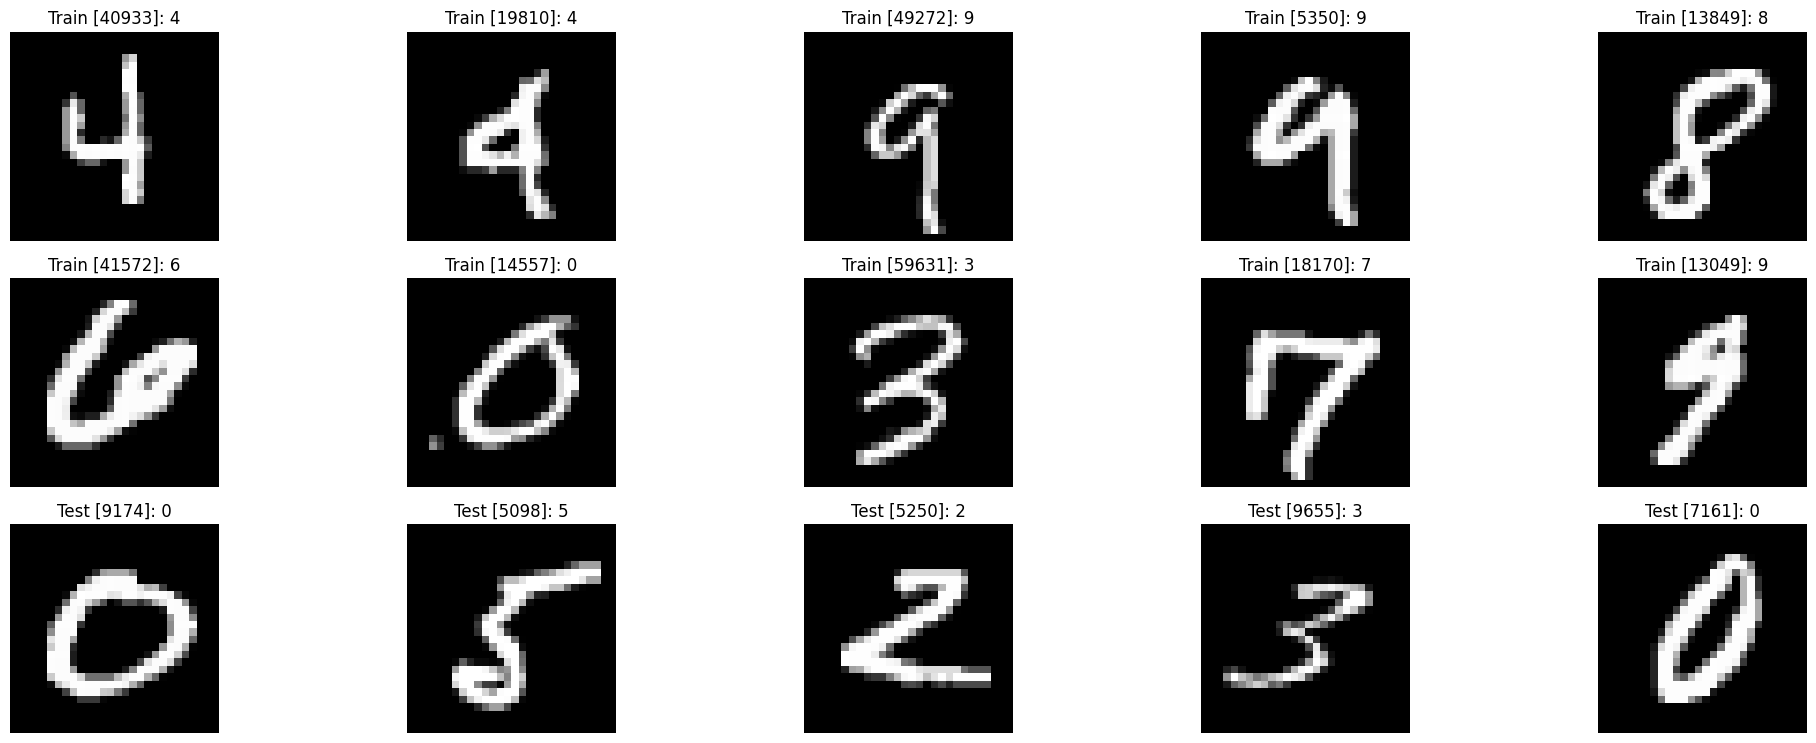

In [3]:
def plot_sample_gallery(images, labels, columns=5):
    """Generates a grid of images with corresponding labels."""
    total_images = len(images)
    rows = (total_images // columns) + 1

    plt.figure(figsize=(20, 10)) # Adjusted for better screen fitting

    for i, (img, lbl) in enumerate(zip(images, labels)):
        plt.subplot(rows, columns, i + 1)
        plt.imshow(img, cmap='gray')
        plt.title(lbl, fontsize=12)
        plt.axis('off') # Hides the x/y ticks for a cleaner look

    plt.tight_layout()
    plt.show()

# Select random indices for a mixed sample
train_idx = random.sample(range(len(X_train)), 10)
test_idx = random.sample(range(len(X_test)), 5)

# Build the display lists
display_images = [X_train[i] for i in train_idx] + [X_test[i] for i in test_idx]
display_titles = [f"Train [{i}]: {y_train[i]}" for i in train_idx] + \
                 [f"Test [{i}]: {y_test[i]}" for i in test_idx]

# Execute visualization
plot_sample_gallery(display_images, display_titles)

## **2.2 Exploratory Data Analysis**

### **Statistical Summary**

In [4]:
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")

X_train: (60000, 28, 28)
X_test: (10000, 28, 28)


In [5]:
print(f"y_train: \n{pd.Series(y_train).value_counts()}\n")
print(f"y_test: \n{pd.Series(y_test).value_counts()}")


y_train: 
1    6742
7    6265
3    6131
2    5958
9    5949
0    5923
6    5918
8    5851
4    5842
5    5421
Name: count, dtype: int64

y_test: 
1    1135
2    1032
7    1028
3    1010
9    1009
4     982
0     980
8     974
6     958
5     892
Name: count, dtype: int64


In [6]:
stats = pd.Series(X_train.flatten()).info()
print(stats)

<class 'pandas.core.series.Series'>
RangeIndex: 47040000 entries, 0 to 47039999
Series name: None
Non-Null Count     Dtype
--------------     -----
47040000 non-null  uint8
dtypes: uint8(1)
memory usage: 44.9 MB
None


In [7]:
stats = pd.Series(X_train.flatten()).describe()
print(stats)

count    4.704000e+07
mean     3.331842e+01
std      7.856749e+01
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      2.550000e+02
dtype: float64




*   Global mean intensity = 33.3, the background mostly dark




### **Correlation Analysis**

In [8]:
#Calculate mean image for each digit (0-9)
mean_images = []

for i in range(10):
  digit_images_mean = X_train[y_train == i].mean(axis=0)
  mean_images.append(digit_images_mean.flatten())

df_means = pd.DataFrame(mean_images)

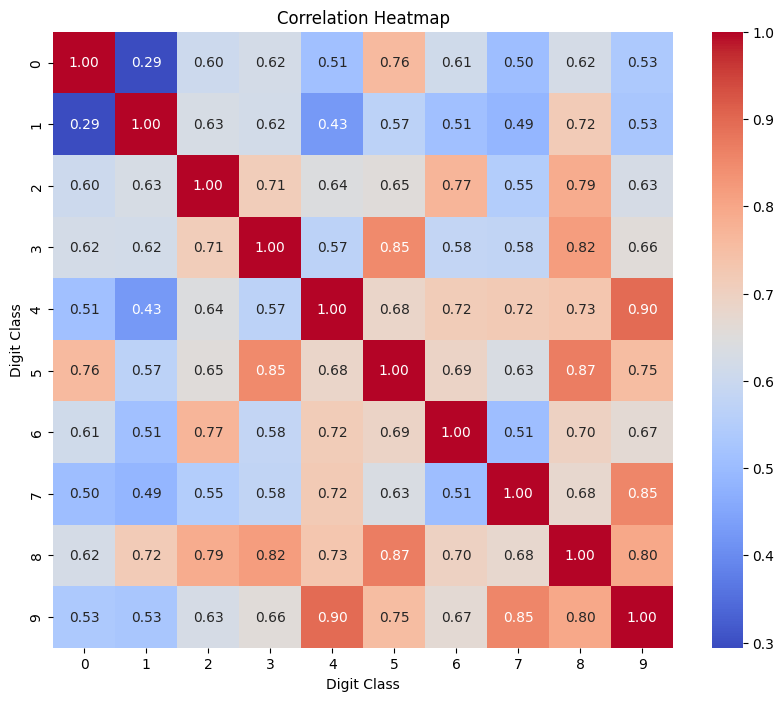

In [9]:
#Compute correlation matrix
corr_matrix = df_means.T.corr()

#Plotting heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm',fmt='.2f')
plt.title("Correlation Heatmap")
plt.xlabel("Digit Class")
plt.ylabel("Digit Class")
plt.show()

*   A value of 1.0 on the diagonal is expected(perfectly correlatred with itself)
*   Off-diagonal values:
1. Strong correlations means that the digits share many same pixels and tend to be similar, which are frequently confused by the model(eg. 0.9 between 4 and 9, 0.87 between 5 and 8, 0.85 between 3 and 5)
2. Weak correlation : The digits not related




### **Trend & Pattern Discovery**

*   Label Distribution


Train Set Digit Distribution:
Digit 0: 5923 samples
Digit 1: 6742 samples
Digit 2: 5958 samples
Digit 3: 6131 samples
Digit 4: 5842 samples
Digit 5: 5421 samples
Digit 6: 5918 samples
Digit 7: 6265 samples
Digit 8: 5851 samples
Digit 9: 5949 samples


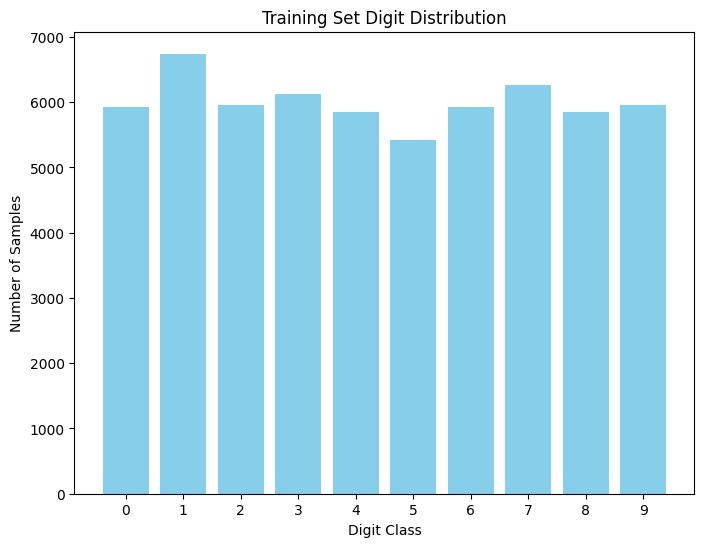

Test Set Digit Distribution:
Digit 0: 980 samples
Digit 1: 1135 samples
Digit 2: 1032 samples
Digit 3: 1010 samples
Digit 4: 982 samples
Digit 5: 892 samples
Digit 6: 958 samples
Digit 7: 1028 samples
Digit 8: 974 samples
Digit 9: 1009 samples


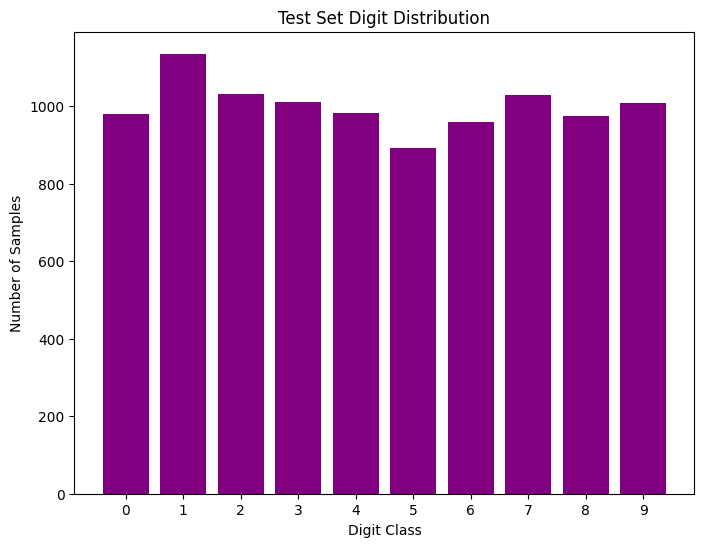

In [10]:
#In Training Set
unique_train_idx,count_train = np.unique(y_train, return_counts=True)
print("Train Set Digit Distribution:")
for digit, count in zip(unique_train_idx, count_train):
  print(f"Digit {digit}: {count} samples")

plt.figure(figsize=(8, 6))
plt.bar(unique_train_idx, count_train, color='skyblue')
plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.title("Training Set Digit Distribution")
plt.xticks(unique_train_idx)
plt.show()

#In Training Set
unique_test_idx,count_train = np.unique(y_test, return_counts=True)
print("Test Set Digit Distribution:")
for digit, count in zip(unique_test_idx, count_train):
  print(f"Digit {digit}: {count} samples")

plt.figure(figsize=(8, 6))
plt.bar(unique_test_idx, count_train, color='purple')
plt.xlabel("Digit Class")
plt.ylabel("Number of Samples")
plt.title("Test Set Digit Distribution")
plt.xticks(unique_test_idx)
plt.show()

*   Pixel Intensity Distribution



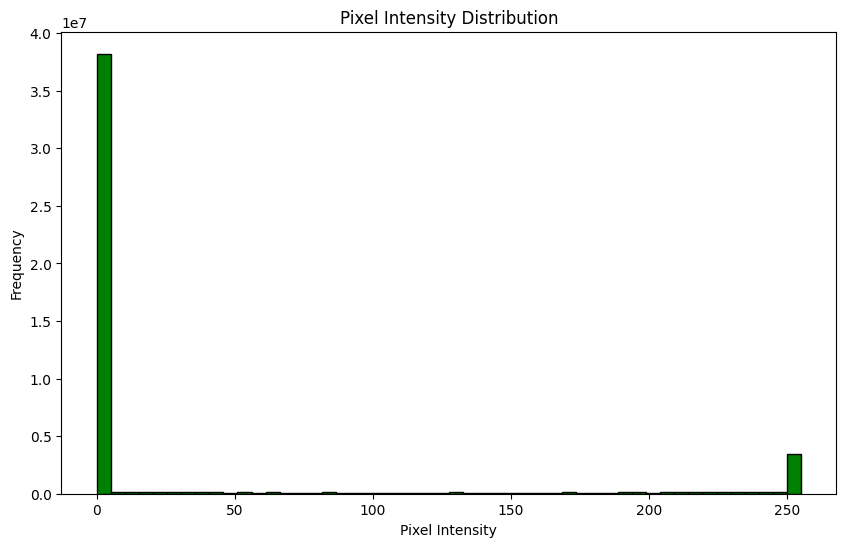

In [11]:
#Flatten all images
flattened_images = X_train.flatten()

plt.figure(figsize=(10, 6))
plt.hist(flattened_images, bins=50, color='green', edgecolor='black')
plt.title("Pixel Intensity Distribution")
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.show()

*   Massive pillar at 0, that is background
*   Small cluster at 255, that is handwriting lines
* The value in the middle represent the edge of the lines where smoothing occurs.
A: This data is "sparse". Most pixels no info most of the time.



* Mean Image

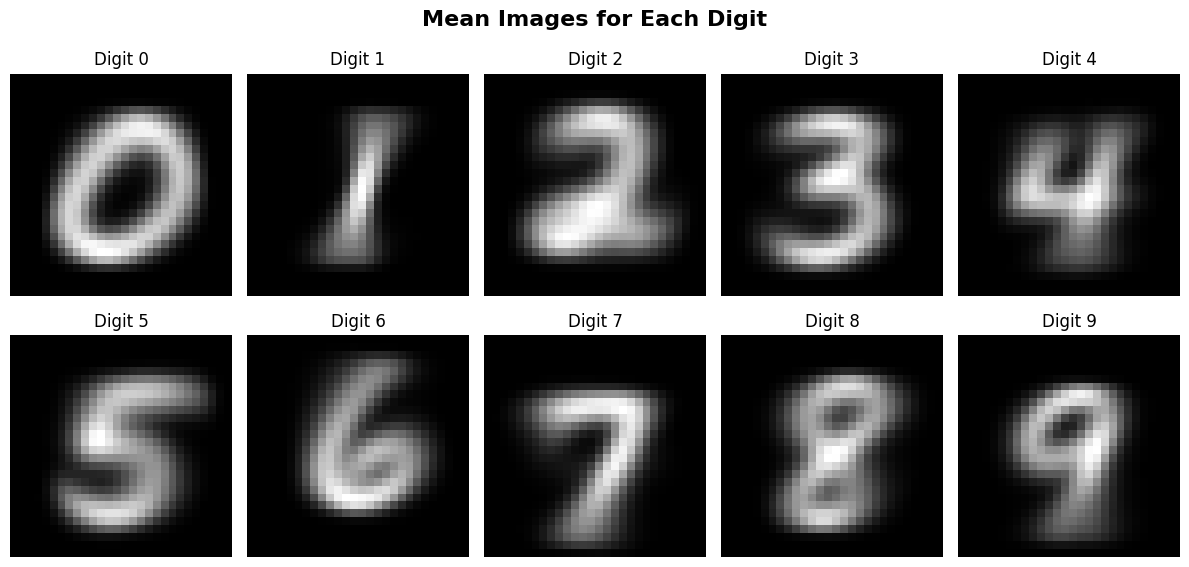

In [12]:
fig, axes = plt.subplots(2, 5, figsize=(12, 6))
fig.suptitle("Mean Images for Each Digit", fontsize=16, fontweight='bold')

for i in range(10):
  row = i // 5
  col = i % 5
  ax = axes[row,col]

  #Filter all digit classes
  digit_subset = X_train[y_train==i]

  #Calculate the mean image along the batch axis
  mean_image = digit_subset.mean(axis=0)

  #Plot average image
  ax.imshow(mean_image.reshape(28, 28), cmap='gray')
  ax.set_title(f"Digit {i}")
  ax.axis('off')

plt.tight_layout()
plt.show()

## **2.3 Data Cleaning**

### **Verifying Dimensionality**

In [13]:
# Validating the structure of the dataset
print(f"Training Data Shape: {X_train.shape} | Labels: {y_train.shape}")
print(f"Testing Data Shape:  {X_test.shape} | Labels: {y_test.shape}")

Training Data Shape: (60000, 28, 28) | Labels: (60000,)
Testing Data Shape:  (10000, 28, 28) | Labels: (10000,)


### **Missing Value Inspection**

In [14]:
# Ensure there are no missing entries (NaNs) in the arrays
print(f"Missing values (Train): {np.isnan(X_train).sum()}")
print(f"Missing values (Test):  {np.isnan(X_test).sum()}")

Missing values (Train): 0
Missing values (Test):  0


### **Analyzing Intensity Distribution**

In [15]:
# Confirming the raw data range (expecting 0 - 255)
print(f"Train Range: {X_train.min()} to {X_train.max()}")
print(f"Test Range:  {X_test.min()} to {X_test.max()}")

Train Range: 0 to 255
Test Range:  0 to 255


### **Feature Scaling and Vectorization**

In [16]:
# Convert to float32, scale to [0, 1], and flatten 28x28 images to 784 vectors
X_train = X_train.reshape(len(X_train), -1).astype("float32") / 255.0
X_test  = X_test.reshape(len(X_test), -1).astype("float32") / 255.0

# Verify the transformation results
print(f"New flattened shape (Train): {X_train.shape}")
print(f"Scaled pixel range: {X_train.min()} - {X_train.max()}")
print(f"New numeric type: {X_train.dtype}")


New flattened shape (Train): (60000, 784)
Scaled pixel range: 0.0 - 1.0
New numeric type: float32


In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### **Data Deduplication**

In [18]:
# --- Process Training Set ---
# Identifying indices for unique samples to filter out redundant data
_, unique_train_idx = np.unique(X_train, axis=0, return_index=True)
X_train = X_train[unique_train_idx]
y_train = y_train[unique_train_idx]

# --- Process Testing Set ---
# Applying the same deduplication logic to the test partition
_, unique_test_idx = np.unique(X_test, axis=0, return_index=True)
X_test = X_test[unique_test_idx]
y_test = y_test[unique_test_idx]

# Display final dataset dimensions
print(f"Post-deduplication Training Shape: {X_train.shape}")
print(f"Post-deduplication Testing Shape:  {X_test.shape}")

Post-deduplication Training Shape: (60000, 784)
Post-deduplication Testing Shape:  (10000, 784)


### **Feature Engineering Documentation**

In [19]:
# --- Data Engineering Summary ---
# To prepare the raw image data for Machine Learning algorithms:
# 1. Dimensionality Reduction: Reshaped 28x28 matrices into 784-element vectors.
# 2. Feature Scaling: Normalized pixel intensities from [0, 255] to [0.0, 1.0]
#    to ensure faster convergence and prevent bias toward high-intensity pixels.

print("Feature engineering complete: Data is scaled and vectorized.")

Feature engineering complete: Data is scaled and vectorized.


### **Final Data Integrity Audit**

In [20]:
# Final validation of the preprocessed dataset
data_summary = pd.DataFrame({
    "Set": ["Training", "Testing"],
    "Samples": [X_train.shape[0], X_test.shape[0]],  # Fixed the bracket here
    "Features": [X_train.shape[1], X_test.shape[1]],
    "Min Pixel": [X_train.min(), X_test.min()],
    "Max Pixel": [X_train.max(), X_test.max()]
})

print("Pre-Training Data Audit:")
print(data_summary)

Pre-Training Data Audit:
        Set  Samples  Features  Min Pixel   Max Pixel
0  Training    60000       784  -1.274208  244.946945
1   Testing    10000       784  -1.274208  419.646423


# **3.0 Model Development, Model Evaluation & Comparative Analysis**

## **Model Evaluation Utilities**

In [21]:
def plot_confusion_matrix(matrix, title="Performance Analysis: Confusion Matrix"):
    """
    Renders a heatmap to visualize the model's classification accuracy.
    This helps identify which digits are being frequently misclassified.
    """
    plt.figure(figsize=(8, 6))

    # Utilizing Seaborn for a clear, annotated heatmap
    sns.heatmap(matrix, annot=True, fmt='d', cmap='Blues')

    # Adding descriptive axis labels for the technical report
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.title(title)
    plt.show()

In [22]:
def plot_multiclass_pr_curve(y_true, y_score, title="Multi-Class Precision-Recall Analysis"):
    """
    Computes and plots PR curves for all 10 digit classes.
    This utility evaluates the tradeoff between precision and recall for
    each individual category.
    """
    # Transform labels into a binary format for multi-label evaluation
    digit_classes = np.arange(10)
    y_true_bin = label_binarize(y_true, classes=digit_classes)

    plt.figure(figsize=(10, 8))

    # Iterate through each digit (0-9) to generate individual curves
    for i in range(len(digit_classes)):
        precision, recall, _ = precision_recall_curve(y_true_bin[:, i], y_score[:, i])
        ap_score = average_precision_score(y_true_bin[:, i], y_score[:, i])

        plt.plot(recall, precision, lw=2, label=f"Digit {i} (Avg Prec: {ap_score:.2f})")

    # Formatting the visual output
    plt.xlabel("Recall (Sensitivity)")
    plt.ylabel("Precision (Positive Predictive Value)")
    plt.title(title, fontsize=14)
    plt.legend(loc="best", fontsize='small', ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

In [23]:
def plot_multiclass_roc_curve(model, title="Multiclass ROC Analysis (Cross-Validated)"):
    """
    Computes Receiver Operating Characteristic (ROC) curves and Area Under the Curve (AUC)
    for each digit using a 5-fold cross-validation strategy on the test set.
    """
    # Convert labels to binary format for one-vs-rest calculation
    digit_classes = np.arange(10)
    y_test_bin = label_binarize(y_test, classes=digit_classes)
    n_classes = y_test_bin.shape[1]

    # Generate cross-validated probability estimates
    # Method is set to 'predict_proba' to get the confidence scores for each class
    y_score = cross_val_predict(model, X_test, y_test, cv=5, method="predict_proba")

    plt.figure(figsize=(10, 8))

    # Calculate and plot the ROC/AUC for each specific digit
    for i in range(n_classes):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        area_under_curve = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2, label=f"Digit {i} (AUC = {area_under_curve:.2f})")

    # Reference line for a random (baseline) classifier
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', label="Random Classifier")

    plt.xlabel("False Positive Rate (1 - Specificity)")
    plt.ylabel("True Positive Rate (Sensitivity)")
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right", fontsize='small', ncol=2)
    plt.grid(alpha=0.3)
    plt.show()

In [24]:
def plot_micro_average_roc(model, X_input, y_true, title="Global Model Performance: Micro-Average ROC"):
    """
    Computes and visualizes the micro-average ROC curve.
    This metric aggregates the contributions of all classes to compute
    an average performance score across the entire dataset.
    """
    # Binarize the target labels for multi-class compatibility
    y_true_bin = label_binarize(y_true, classes=np.arange(10))

    # Generate probability scores for the input features
    # This assumes the model has already been fitted
    y_score = model.predict_proba(X_input)

    # Compute micro-average metrics by flattening (raveling) the arrays
    # This treats the multi-class problem as a single global binary classification
    fpr_micro, tpr_micro, _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
    roc_auc_micro = auc(fpr_micro, tpr_micro)

    plt.figure(figsize=(8, 6))

    # Plotting the micro-average curve with high visibility
    plt.plot(fpr_micro, tpr_micro,
             label=f"Micro-average ROC (AUC = {roc_auc_micro:.2f})",
             color='deeppink', linewidth=3)

    # Reference diagonal line representing a random guess
    plt.plot([0, 1], [0, 1], color='black', linestyle='--', alpha=0.7)

    plt.xlabel("False Positive Rate (Global)")
    plt.ylabel("True Positive Rate (Global)")
    plt.title(title, fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.show()

In [25]:
def visualize_correct_predictions(y_pred, title="Model Success Analysis: Correct Classifications"):
    """
    Identifies and displays a sample of images where the model's prediction
    perfectly matches the ground truth label.
    """
    # Create a mask to filter only successful predictions
    is_correct = (y_test == y_pred)
    correct_indices = np.where(is_correct)[0][:9]

    # Initialize a focused grid for visualization
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(correct_indices):
        plt.subplot(1, 9, i + 1)

        # Reshape the flattened 1D vector back to 2D 28x28 for display
        img_pixel_matrix = X_test[idx].reshape(28, 28)

        plt.imshow(img_pixel_matrix, cmap='gray')
        plt.title(f"Actual: {y_test[idx]}\nPred: {y_pred[idx]}",
                  fontsize=9, color='forestgreen')
        plt.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [26]:
def visualize_misclassifications(y_pred, title="Error Analysis: Sample Misclassifications"):
    """
    Extracts and displays instances where the model's prediction diverged
    from the actual label. This is critical for identifying specific
    digit patterns that confuse the classifier.
    """
    # Create a mask to isolate the errors
    is_incorrect = (y_test != y_pred)
    error_indices = np.where(is_incorrect)[0][:9]

    # Initialize a clean visualization grid
    plt.figure(figsize=(12, 4))

    for i, idx in enumerate(error_indices):
        plt.subplot(1, 9, i + 1)

        # Reconstructing the image from the flattened feature vector
        img_data = X_test[idx].reshape(28, 28)

        plt.imshow(img_data, cmap='gray')

        # Highlighting the discrepancy in red to signify an error
        plt.title(f"Actual: {y_test[idx]}\nPred: {y_pred[idx]}",
                  fontsize=9, color='crimson')
        plt.axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [27]:
def compare_train_test_accuracy(model, title="Bias-Variance Analysis: Training vs. Testing"):
    """
    Computes and visualizes the accuracy gap between training and test sets.
    This comparison is essential for detecting overfitting and assessing
    the model's generalization capabilities.
    """
    # Generating predictions for both subsets
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    # Quantifying accuracy scores
    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_test_pred)

    # Visualization Setup
    plt.figure(figsize=(6, 5))
    labels = ['Training Set', 'Testing Set']
    scores = [train_acc, test_acc]
    colors = ['skyblue', 'salmon']

    # Creating the bar chart
    bars = plt.bar(labels, scores, color=colors, alpha=0.8, edgecolor='black', linewidth=1)

    plt.title(title, fontsize=13, fontweight='bold', pad=20)
    plt.ylabel('Accuracy Score (0.0 - 1.0)')

    # Adjusting Y-axis to provide visual "headroom" for labels
    plt.ylim(0, 1.1)

    # Adding numerical annotations on top of bars for precision
    plt.bar_label(bars, labels=[f'{s:.4f}' for s in scores],
                 padding=5, fontweight='bold')

    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [28]:
def analyze_error_rates_per_class(y_pred, title="Error Distribution: Misclassification Rate by Digit"):
    """
    Calculates and visualizes the percentage of errors for each digit class.
    Sorting the classes by error rate allows for immediate identification
    of the most challenging digits for the classifier.
    """
    # Define digit labels and calculate occurrence counts
    classes = np.arange(10)
    total_counts = np.array([(y_test == d).sum() for d in classes])

    # Identify count of incorrect predictions per specific digit
    mistake_counts = np.array([((y_test == d) & (y_pred != d)).sum() for d in classes])

    # Compute error rate (mistakes / total) with safety check for zero division
    error_rates = np.divide(mistake_counts, total_counts,
                            out=np.zeros_like(mistake_counts, dtype=float),
                            where=total_counts > 0)

    # Sort data by highest error rate for better report storytelling
    sorted_indices = np.argsort(error_rates)[::-1]
    sorted_classes = classes[sorted_indices]
    sorted_rates = error_rates[sorted_indices]

    # Visualization: Horizontal Bar Chart
    fig, ax = plt.subplots(figsize=(10, 6), dpi=80)
    bars = ax.barh(sorted_classes, sorted_rates, height=0.7, color='darkred', alpha=0.8)

    # Formatting and Styling
    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Misclassification Percentage', fontsize=12)
    ax.set_ylabel('Digit Category', fontsize=12)
    ax.set_yticks(sorted_classes)

    # Formatting X-axis as percentages (e.g., 10%)
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))

    # Adding numerical labels to the end of each bar
    for bar, val in zip(bars, sorted_rates):
        ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                f'{val:.1%}', va='center', ha='left',
                fontsize=11, fontweight='bold', color='darkred')

    ax.grid(axis='x', alpha=0.3, linestyle='--')
    ax.invert_yaxis()  # Most misclassified digits appear at the top
    plt.tight_layout()
    plt.show()

In [29]:
def plot_top_confusion_pairs(confusion_matrix, title="Inter-class Confusion: Top 10 Error Pairs"):
    """
    Identifies the most frequent misclassification pairs by isolating
    off-diagonal values in the confusion matrix.
    """
    # Create a copy to manipulate and remove correct classifications (diagonal)
    cm_off_diag = confusion_matrix.copy()
    np.fill_diagonal(cm_off_diag, 0)

    # Locate indices where misclassifications occurred
    actual_idx, predicted_idx = np.where(cm_off_diag > 0)
    error_counts = cm_off_diag[actual_idx, predicted_idx]

    # Sort errors in descending order to find the most significant confusions
    sorted_indices = np.argsort(error_counts)[::-1]
    top_k = min(10, len(sorted_indices))

    actual_idx = actual_idx[sorted_indices[:top_k]]
    predicted_idx = predicted_idx[sorted_indices[:top_k]]
    top_error_values = error_counts[sorted_indices[:top_k]]

    # Generate labels (e.g., "Actual -> Predicted")
    labels = [f"Actual {a} → Pred {p}" for a, p in zip(actual_idx, predicted_idx)]

    # Visualization: Horizontal Bar Chart
    plt.figure(figsize=(9, 6))
    bars = plt.barh(np.arange(top_k), top_error_values, color='orange', alpha=0.9)

    plt.title(title, fontsize=16, fontweight='bold', pad=20)
    plt.xlabel('Frequency of Occurrence', fontsize=12)
    plt.ylabel('Misclassification Pair', fontsize=12)
    plt.yticks(np.arange(top_k), labels)
    plt.gca().invert_yaxis()  # Rank 1 confusion at the top

    # Annotate bars with numerical counts
    for i, val in enumerate(top_error_values):
        plt.text(val + (max(top_error_values)*0.01), i, f'{int(val)}',
                 va='center', fontweight='bold', fontsize=11,
                 bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='orange', alpha=0.8))

    plt.grid(axis='x', alpha=0.2, linestyle='--')
    plt.tight_layout()
    plt.show()

In [30]:
def plot_cross_validation_consistency(cv_scores, title="Model Generalization: 5-Fold CV Accuracy"):
    """
    Visualizes the accuracy across multiple validation folds to ensure
    model stability and verify that the performance is not split-dependent.
    """
    plt.figure(figsize=(8, 5))

    # Plotting the accuracy of each fold
    folds = range(1, len(cv_scores) + 1)
    plt.plot(folds, cv_scores, marker='o', linestyle='-', color='royalblue',
             linewidth=2, markersize=8, label='Fold Accuracy')

    # Adding a reference line for the mean accuracy
    mean_score = np.mean(cv_scores)
    plt.axhline(mean_score, color='red', linestyle='--', alpha=0.6,
                label=f'Mean Accuracy ({mean_score:.4f})')

    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Validation Fold Number', fontsize=12)
    plt.ylabel('Accuracy Score', fontsize=12)

    # Setting dynamic limits to zoom in on the variance
    plt.ylim(min(cv_scores) - 0.005, max(cv_scores) + 0.005)

    plt.xticks(folds)
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

In [31]:
def plot_learning_diagnostics(estimator, X, y, title="Learning Curve: Bias-Variance Assessment", cv=5):
    """
    Generates a diagnostic plot comparing training and cross-validation scores
    relative to the amount of training data used.
    Essential for identifying underfitting (high bias) and overfitting (high variance).
    """
    plt.figure(figsize=(10, 6))
    plt.title(title, fontsize=14, fontweight='bold', pad=15)
    plt.xlabel("Size of Training Subset (Samples)", fontsize=12)
    plt.ylabel("Accuracy Score", fontsize=12)

    # Compute learning curve data points
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=cv, n_jobs=-1, train_sizes=np.linspace(0.1, 1.0, 5)
    )

    # Calculate mean and standard deviation for shading
    train_mean = np.mean(train_scores, axis=1)
    train_std = np.std(train_scores, axis=1)
    test_mean = np.mean(test_scores, axis=1)
    test_std = np.std(test_scores, axis=1)

    plt.grid(True, linestyle='--', alpha=0.6)

    # Fill areas to represent variance/uncertainty
    plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std,
                     alpha=0.15, color="crimson")
    plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std,
                     alpha=0.15, color="forestgreen")

    # Plot the mean trend lines
    plt.plot(train_sizes, train_mean, 'o-', color="crimson", label="Training Accuracy")
    plt.plot(train_sizes, test_mean, 'o-', color="forestgreen", label="Cross-Validation Accuracy")

    plt.legend(loc="lower right")
    plt.tight_layout()
    return plt

In [34]:
def show_matrix(cm, class_names, title="Confusion Matrix"):
    """Utility function to plot a styled confusion matrix."""
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
                xticklabels=class_names, yticklabels=class_names)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.show()

## **3.1 Model Training**

### **3.1.1 K-Nearest Neighbors (KNN)**

#### **Primary Model Implementation and Initial Training**

In [35]:
# Initialize the neighbor-based classifier
# Using k=5 as the initial heuristic for the baseline model
knn_model_baseline = KNeighborsClassifier()

# Execute training process on the feature matrix (X_train) and target vector (y_train)
print("Status: Training KNN model on MNIST dataset...")
knn_model_baseline.fit(X_train, y_train)
print("Success: Model weights are now fitted.")

Status: Training KNN model on MNIST dataset...
Success: Model weights are now fitted.


#### **Performance measure: Accuracy, precision, recall, and f1 score**

In [36]:
# Generate class predictions for both data splits
training_predictions = knn_model_baseline.predict(X_train)
testing_predictions = knn_model_baseline.predict(X_test)

# Calculate precision-based accuracy scores
acc_score_train = accuracy_score(y_train, training_predictions)
acc_score_test = accuracy_score(y_test, testing_predictions)

# Quantify the 'Generalization Gap' to detect potential Overfitting
# A gap < 0.05 (5%) generally indicates a healthy model for MNIST
variance_delta = abs(acc_score_train - acc_score_test)

print(f"--- KNN Baseline Results ---")
print(f"Training Accuracy: {acc_score_train:.4f} ({acc_score_train*100:.2f}%)")
print(f"Training Classification Report:\n{classification_report(y_train, training_predictions)}")
print(f"Testing Accuracy:  {acc_score_test:.4f} ({acc_score_test*100:.2f}%)")
print(f"Testing Classification Report:\n{classification_report(y_test, testing_predictions)}")
print(f"Generalization Gap: {variance_delta:.4f}")

--- KNN Baseline Results ---
Training Accuracy: 0.9643 (96.43%)
Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98      5923
           1       0.97      0.99      0.98      6742
           2       0.97      0.96      0.96      5958
           3       0.95      0.97      0.96      6131
           4       0.97      0.95      0.96      5842
           5       0.96      0.95      0.95      5421
           6       0.97      0.98      0.98      5918
           7       0.96      0.96      0.96      6265
           8       0.98      0.93      0.95      5851
           9       0.94      0.95      0.95      5949

    accuracy                           0.96     60000
   macro avg       0.96      0.96      0.96     60000
weighted avg       0.96      0.96      0.96     60000

Testing Accuracy:  0.9443 (94.43%)
Testing Classification Report:
              precision    recall  f1-score   support

           0       0.95 

#### **Hyperparameter Optimization using Grid Search**

In [37]:
# Define the search space for hyperparameter optimization
# We are testing k values (3, 4, 5) and two weighting strategies
search_space = {
    'n_neighbors': [3, 4, 5],
    'weights': ['uniform', 'distance']
}

# Initialize the cross-validation optimizer
# We use 5-fold CV to ensure the results are stable across different data splits
knn_tuner = GridSearchCV(
    estimator=knn_model_baseline, # Reference to your model from 2.1.1
    param_grid=search_space,
    scoring='accuracy',
    cv=5,
    n_jobs=-1  # Parallel processing for faster computation
)

print('System Log: Initializing exhaustive grid search...', end=' ')

# Execute the search on the training data
knn_tuner.fit(X_train, y_train)

print('Done.\n')

# Output the findings for the report
print(f"Optimal Parameter Set: {knn_tuner.best_params_}")
print(f"Highest Mean CV Accuracy: {knn_tuner.best_score_:.4f}")

System Log: Initializing exhaustive grid search... Done.

Optimal Parameter Set: {'n_neighbors': 4, 'weights': 'distance'}
Highest Mean CV Accuracy: 0.8637


### **3.1.2 Logistic Regression**

#### **Model Implementation and Initial Training**

In [38]:
log_reg = LogisticRegression(random_state=42)
print("Training Logistic Regression model on MNIST dataset")
log_reg.fit(X_train, y_train)
print("Success: Model weights are now fitted.")

Training Logistic Regression model on MNIST dataset
Success: Model weights are now fitted.


#### **Performance measure(Train set): Accuracy, precision, recall, and f1 score**

In [39]:
#Perform cv on the training set to evaluate the model
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(log_reg, X_train, y_train, cv=cv)
print(f'Cross-validation scores: {cv_scores}')
print(f'Mean cross-validation score: {cv_scores.mean()}')
print(f'Standard deviation of cross-validation accuracy:', cv_scores.std())

Cross-validation scores: [0.91016667 0.91416667 0.91575    0.91091667 0.9135    ]
Mean cross-validation score: 0.9128999999999999
Standard deviation of cross-validation accuracy: 0.0020732422273659285


The model's performance was evaluated using 5-fold Stratified Cross-Validation with data shuffling.<br>
The use of StratifiedKFold and shuffle ensure the data distributed equally<br>
Low Standard Deviation (**0.0020**) means that the model is highly stable.<br>
A high mean accuracy (**91.28%**) means that the model has a high predictive power.<br>
Thus, this result confirm that the model is robust and ready for the next step.

In [40]:
log_reg_training_predictions = log_reg.predict(X_train)
log_reg_testing_predictions = log_reg.predict(X_test)

log_reg_train_acc_score = accuracy_score(y_train, log_reg_training_predictions)
log_reg_cv_acc_score = accuracy_score(y_test, log_reg_testing_predictions)

variance_delta = log_reg_train_acc_score - cv_scores.mean()

print(f"--- Logistic Regression Results ---")
print(f"Training Accuracy: {log_reg_train_acc_score:.4f} ({log_reg_train_acc_score*100:.2f}%)")
print(f"Training Classification Report:\n{classification_report(y_train, log_reg_training_predictions)}")
print(f"Generalization Gap: {variance_delta:.4f}")

--- Logistic Regression Results ---
Training Accuracy: 0.9433 (94.33%)
Training Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98      5923
           1       0.97      0.98      0.97      6742
           2       0.94      0.93      0.93      5958
           3       0.93      0.92      0.92      6131
           4       0.95      0.95      0.95      5842
           5       0.92      0.91      0.92      5421
           6       0.96      0.97      0.97      5918
           7       0.95      0.95      0.95      6265
           8       0.92      0.91      0.91      5851
           9       0.92      0.93      0.93      5949

    accuracy                           0.94     60000
   macro avg       0.94      0.94      0.94     60000
weighted avg       0.94      0.94      0.94     60000

Generalization Gap: 0.0304


=========<br>
 Summary<br>
=========<br>
High accuracy for both training and testing set, with lower generalization gap means that the model is **good fit**.

#### **Hyperparameter Tuning using Grid Search**

In [41]:
# Define the search space for hyperparameter optimization
# Tune the regularization strength (C) and the solver algorithm
search_space_log_reg = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000]
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Initialize the cross-validation optimizer
# Use 5-fold CV to ensure the results are stable across different data splits
log_reg_tuner = GridSearchCV(
    estimator=log_reg,
    param_grid=search_space_log_reg,
    cv=cv,
    n_jobs=-1,
    verbose=4
)

In [42]:
# Execute the search on the training data
log_reg_tuner.fit(X_train, y_train)

print('Done.\n')

# Output the findings for the report
print(f"Optimal Parameter Set for Logistic Regression: {log_reg_tuner.best_params_}")
print(f"Highest CV Accuracy for Logistic Regression: {log_reg_tuner.best_score_:.4f}")

Fitting 5 folds for each of 8 candidates, totalling 40 fits
Done.

Optimal Parameter Set for Logistic Regression: {'C': 0.01, 'max_iter': 1000, 'solver': 'lbfgs'}
Highest CV Accuracy for Logistic Regression: 0.9224


## **3.2 Model Evaluation**

### **3.2.1 K-Nearest Neighbors (KNN)**

#### **Performance Metrics: Precision, Recall, and F1-Score, CV**

--- Optimized KNN: Final Train Evaluation ---
Overall Accuracy: 1.0000
Precision (Macro): 1.0000
Recall (Macro):    1.0000
F1-Score (Macro):  1.0000

[ Confusion Matrix - Train Set ]


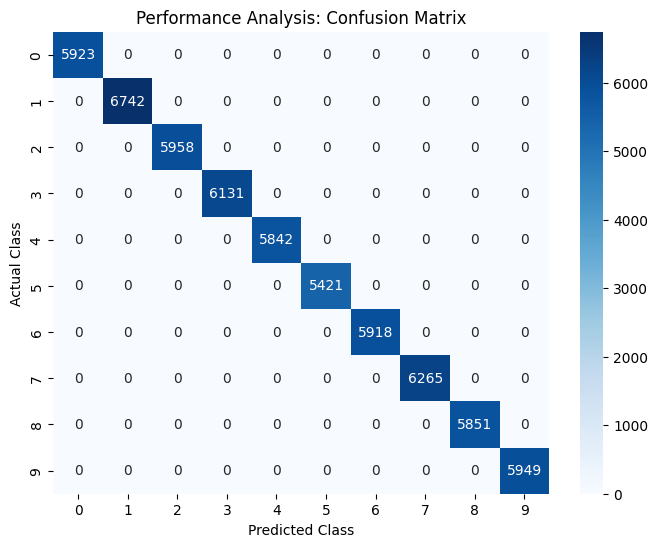

None

[ Detailed Classification Report ]
--- Optimized KNN: Final Test Evaluation ---
Overall Accuracy: 0.9489
Precision (Macro): 0.9488
Recall (Macro):    0.9483
F1-Score (Macro):  0.9484

[ Confusion Matrix - Test Set ]


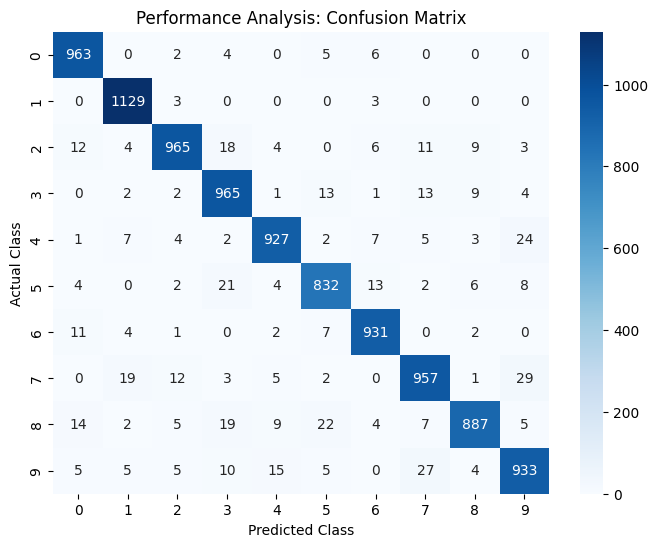

None
Generalization Gap:      0.0511

[ Detailed Classification Report ]
              precision    recall  f1-score   support

           0     0.9535    0.9827    0.9678       980
           1     0.9633    0.9947    0.9788      1135
           2     0.9640    0.9351    0.9493      1032
           3     0.9261    0.9554    0.9405      1010
           4     0.9586    0.9440    0.9513       982
           5     0.9369    0.9327    0.9348       892
           6     0.9588    0.9718    0.9653       958
           7     0.9364    0.9309    0.9337      1028
           8     0.9631    0.9107    0.9361       974
           9     0.9274    0.9247    0.9261      1009

    accuracy                         0.9489     10000
   macro avg     0.9488    0.9483    0.9484     10000
weighted avg     0.9490    0.9489    0.9488     10000



In [91]:
# Retrieve the optimized model from the tuning phase
optimized_knn = knn_tuner.best_estimator_

# Generate final predictions on the unseen test data
final_train_preds_knn = optimized_knn.predict(X_train)
final_test_preds_knn = optimized_knn.predict(X_test)

# Calculate comprehensive classification metrics
# We use 'macro' averaging to give equal weight to each digit class (0-9)
tuned_train_acc_knn  = accuracy_score(y_train, final_train_preds_knn)
tuned_train_prec_acc_knn = precision_score(y_train, final_train_preds_knn, average="macro", zero_division=0)
tuned_train_rec_acc_knn  = recall_score(y_train, final_train_preds_knn, average="macro", zero_division=0)
tuned_train_f1_acc_knn   = f1_score(y_train, final_train_preds_knn, average="macro", zero_division=0)

print("--- Optimized KNN: Final Train Evaluation ---")
print(f"Overall Accuracy: {tuned_train_acc_knn:.4f}")
print(f"Precision (Macro): {tuned_train_prec_acc_knn:.4f}")
print(f"Recall (Macro):    {tuned_train_rec_acc_knn:.4f}")
print(f"F1-Score (Macro):  {tuned_train_f1_acc_knn:.4f}")

print("\n[ Confusion Matrix - Train Set ]")
print(plot_confusion_matrix(confusion_matrix(y_train, final_train_preds_knn)))

# Detailed per-class breakdown
print("\n[ Detailed Classification Report ]")
#print(classification_report(y_test, final_train_preds_knn, digits=4, zero_division=0))

tuned_test_acc_knn  = accuracy_score(y_test, final_test_preds_knn)
tuned_test_prec_acc_knn = precision_score(y_test, final_test_preds_knn, average="macro", zero_division=0)
tuned_test_rec_acc_knn  = recall_score(y_test, final_test_preds_knn, average="macro", zero_division=0)
tuned_test_f1_acc_knn   = f1_score(y_test, final_test_preds_knn, average="macro", zero_division=0)

# Quantify the final variance between training and testing performance
final_variance_gap_log_reg = abs(tuned_train_acc_knn - tuned_test_acc_knn)

print("--- Optimized KNN: Final Test Evaluation ---")
print(f"Overall Accuracy: {tuned_test_acc_knn:.4f}")
print(f"Precision (Macro): {tuned_test_prec_acc_knn:.4f}")
print(f"Recall (Macro):    {tuned_test_rec_acc_knn:.4f}")
print(f"F1-Score (Macro):  {tuned_test_f1_acc_knn:.4f}")

print("\n[ Confusion Matrix - Test Set ]")
print(plot_confusion_matrix(confusion_matrix(y_test, final_test_preds_knn)))

print(f"Generalization Gap:      {final_variance_gap_log_reg:.4f}")

# Detailed per-class breakdown
print("\n[ Detailed Classification Report ]")
print(classification_report(y_test, final_test_preds_knn, digits=4, zero_division=0))

In [92]:
# Execute 5-fold cross-validation to ensure performance is consistent
# Using n_jobs=-1 to utilize all CPU cores for faster computation
knn_cv_results = cross_val_score(
    estimator=optimized_knn,  # <--- Change this to your actual model name if needed!
    X=X_test,
    y=y_test,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Output the diagnostic metrics in a clean format
print("[ Cross-Validation Stability Audit ]")
print(f"Individual Fold Accuracies: {knn_cv_results}")
print(f"Overall Mean Accuracy:      {knn_cv_results.mean():.4f}")

[ Cross-Validation Stability Audit ]
Individual Fold Accuracies: [0.7345 0.887  0.917  0.877  0.8065]
Overall Mean Accuracy:      0.8444


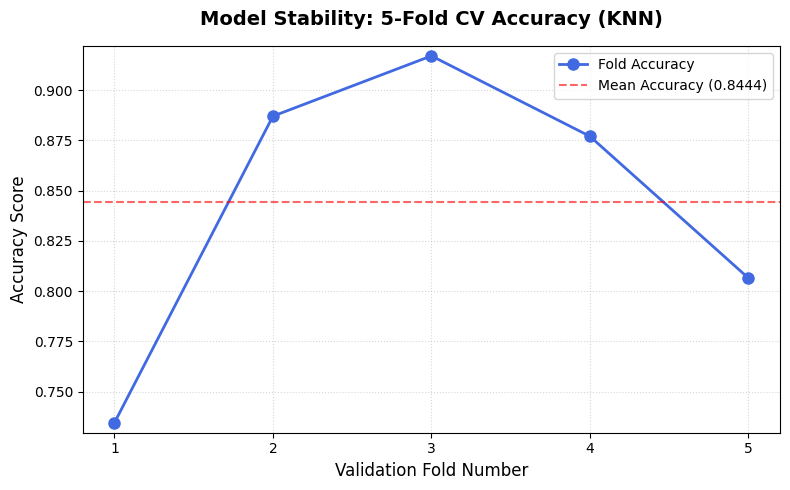

In [93]:
# Generate a line plot to verify the consistency across all 5 folds
plot_cross_validation_consistency(
    knn_cv_results,
    title="Model Stability: 5-Fold CV Accuracy (KNN)"
)

#### **Granular Analysis: Performance Metrics per Digit Class**

In [94]:
# Calculate specific metrics for every digit (0-9)
prec_list, rec_list, f1_list, sup_list = precision_recall_fscore_support(y_test, final_test_preds_knn)

# Construct a summary table for comparative analysis
digit_performance_summary = pd.DataFrame({
    'Digit_Label': [f"Digit {i}" for i in range(10)],
    'Precision': prec_list,
    'Recall': rec_list,
    'F1_Score': f1_list,
    'Sample_Count': sup_list
})

# Display the performance table
# Rounding to 4 decimal places for academic precision
print("\n[ Final KNN Performance per Digit ]")
print(digit_performance_summary.round(4).to_string(index=False))

# Optional: Identify the most difficult digit
weakest_digit = digit_performance_summary.loc[digit_performance_summary['F1_Score'].idxmin()]
print(f"\nAnalysis Note: {weakest_digit['Digit_Label']} appears most challenging with an F1-Score of {weakest_digit['F1_Score']:.4f}")


[ Final KNN Performance per Digit ]
Digit_Label  Precision  Recall  F1_Score  Sample_Count
    Digit 0     0.9535  0.9827    0.9678           980
    Digit 1     0.9633  0.9947    0.9788          1135
    Digit 2     0.9640  0.9351    0.9493          1032
    Digit 3     0.9261  0.9554    0.9405          1010
    Digit 4     0.9586  0.9440    0.9513           982
    Digit 5     0.9369  0.9327    0.9348           892
    Digit 6     0.9588  0.9718    0.9653           958
    Digit 7     0.9364  0.9309    0.9337          1028
    Digit 8     0.9631  0.9107    0.9361           974
    Digit 9     0.9274  0.9247    0.9261          1009

Analysis Note: Digit 9 appears most challenging with an F1-Score of 0.9261


#### **Error Visualization: Cross-Validated Confusion Matrix**

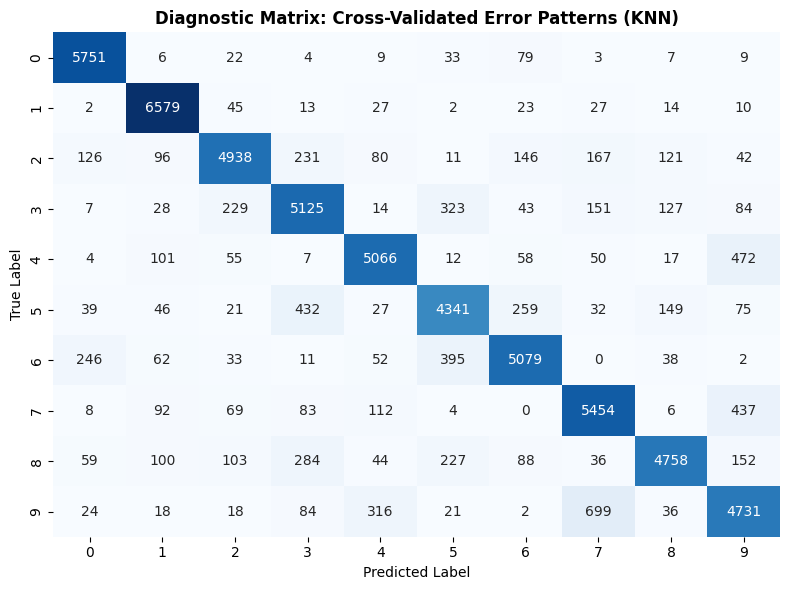

In [96]:
# Generate cross-validated predictions for the training set
# This provides a more generalized view of potential error patterns
cv_predictions_train = cross_val_predict(optimized_knn, X_train, y_train, cv=5)

# Construct the confusion matrix based on CV results
knn_confusion_matrix = confusion_matrix(y_train, cv_predictions_train)

# Converting digit integers to strings for clear labeling
digit_labels = [str(digit) for digit in range(10)]

# Visualize the matrix using the newly defined utility
show_matrix(
    knn_confusion_matrix,
    class_names=digit_labels,
    title="Diagnostic Matrix: Cross-Validated Error Patterns (KNN)"
)

#### **Error Visualization: Test Set Confusion Matrix**

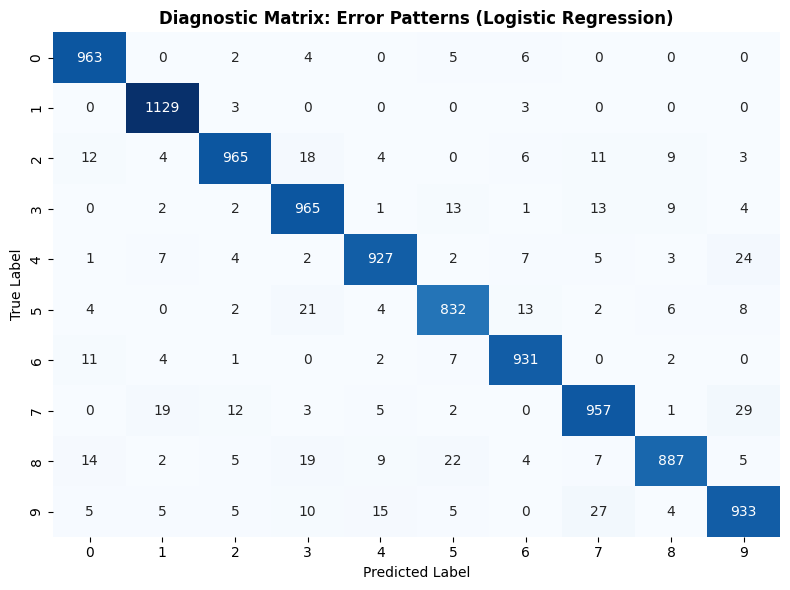

In [97]:
knn_confusion_matrix_test = confusion_matrix(y_test, final_test_preds_knn)

# Converting digit integers to strings for clear labeling
digit_labels = [str(digit) for digit in range(10)]

# Visualize the matrix using the utility function
show_matrix(
    knn_confusion_matrix_test,
    class_names=digit_labels,
    title="Diagnostic Matrix: Error Patterns (Logistic Regression)"
)

#### **Performance Measure: Precision-Recall curve**

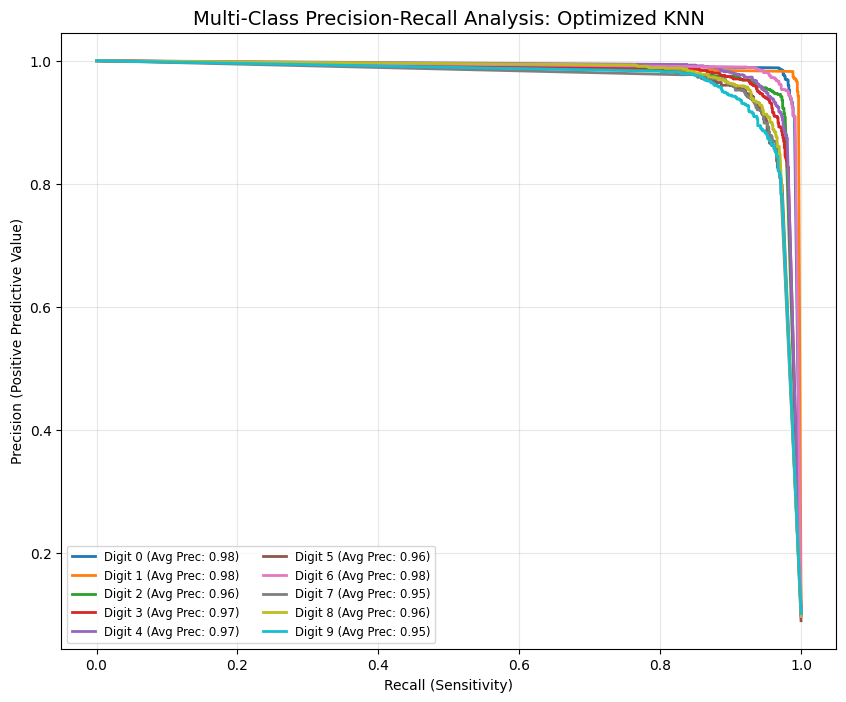

In [99]:
# Generate the multi-class Precision-Recall visual analysis
# Utilizing cross-validated test predictions for a generalized evaluation
final_test_probs_knn = optimized_knn.predict_proba(X_test)
plot_multiclass_pr_curve(
    y_test,
    final_test_probs_knn,
    title="Multi-Class Precision-Recall Analysis: Optimized KNN"
)

#### **Performance Evaluation: Receiver Operating Characteristic (ROC) Analysis**

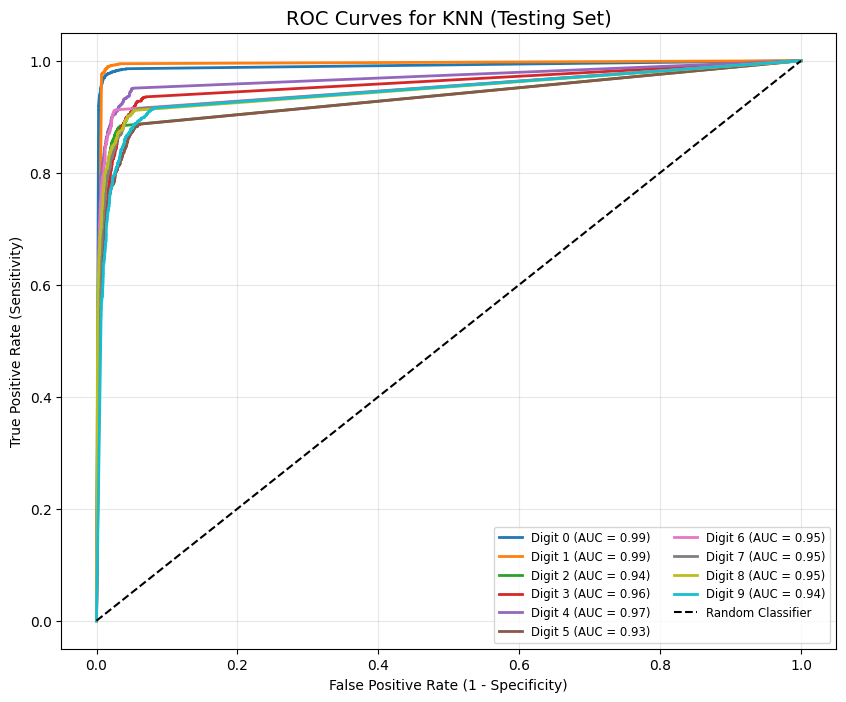

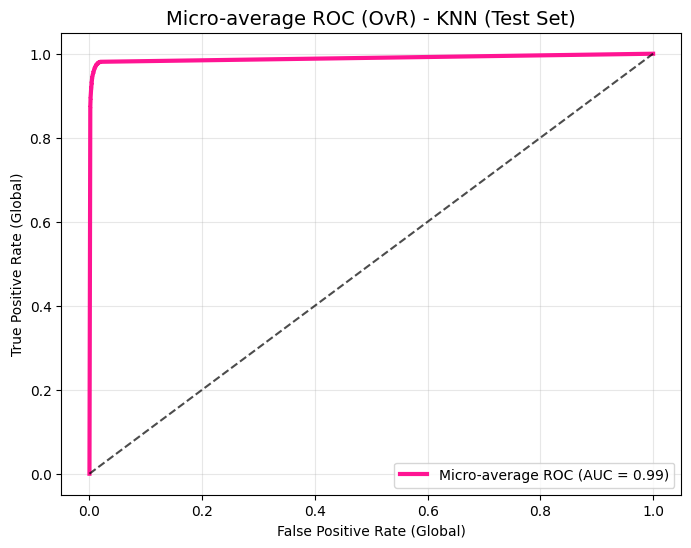

In [100]:
# 1. Class-Specific ROC Analysis
plot_multiclass_roc_curve(
    optimized_knn,
    title='ROC Curves for KNN (Testing Set)'
)

# 2. Global Performance: Micro-Average ROC
plot_micro_average_roc(
    optimized_knn,
    X_test,
    y_test,
    title="Micro-average ROC (OvR) - KNN (Test Set)"
)

#### **Performance Evaluation: Visual Analysis of Classification Outcomes**

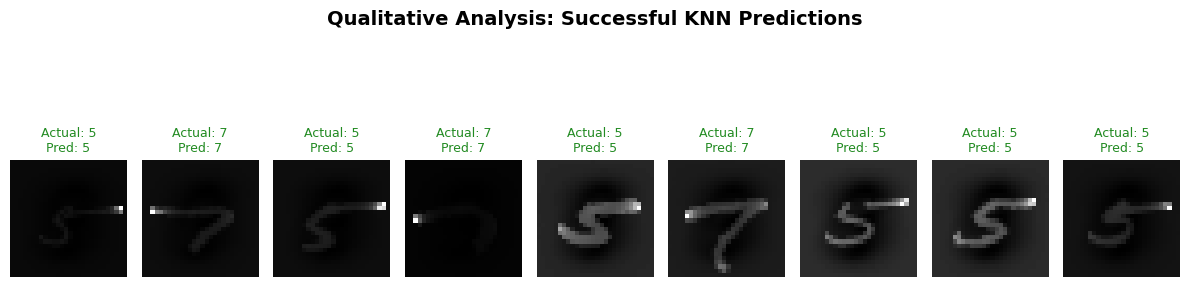

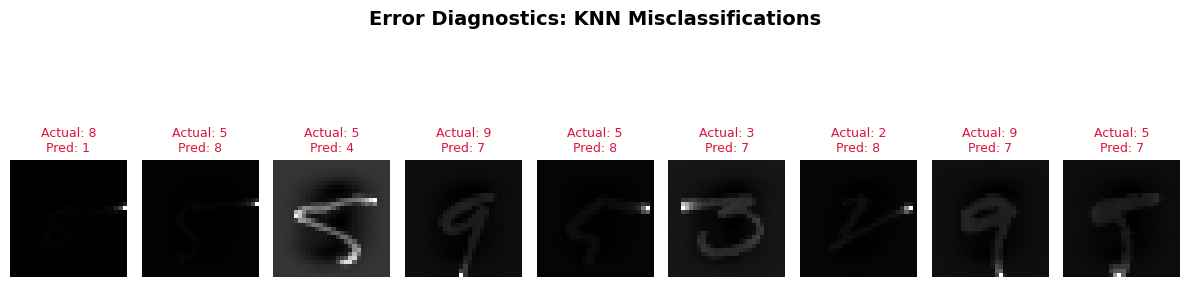

In [101]:
# ==========================================
# 1. Visualizing Successful Classifications
# ==========================================
# Generates a grid of test images where the model perfectly matched the ground truth.
# This confirms the model's ability to recognize standard digit patterns.
visualize_correct_predictions(
    testing_predictions,
    title='Qualitative Analysis: Successful KNN Predictions'
)

# ==========================================
# 2. Visualizing Model Errors (Misclassifications)
# ==========================================
# Generates a grid of test images where the model's prediction diverged from the true label.
# This is critical for identifying specific edge cases and "confusing" handwriting styles.
visualize_misclassifications(
    testing_predictions,
    title='Error Diagnostics: KNN Misclassifications'
)

#### **Comprehensive Diagnostic Visualizations: Deep-Dive Insights**

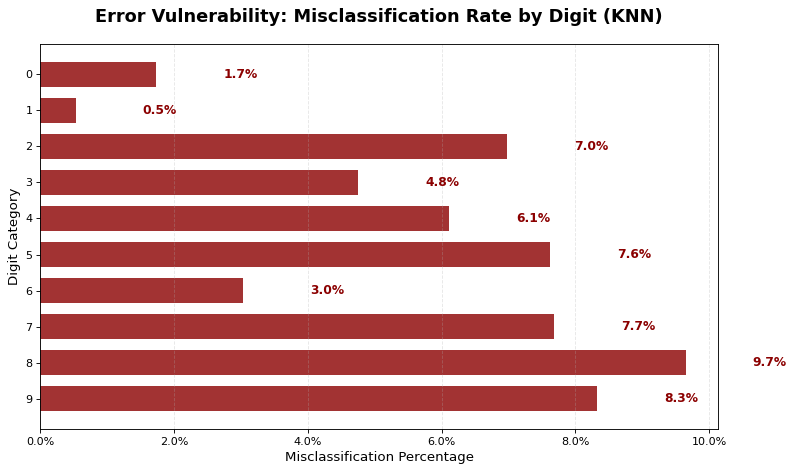

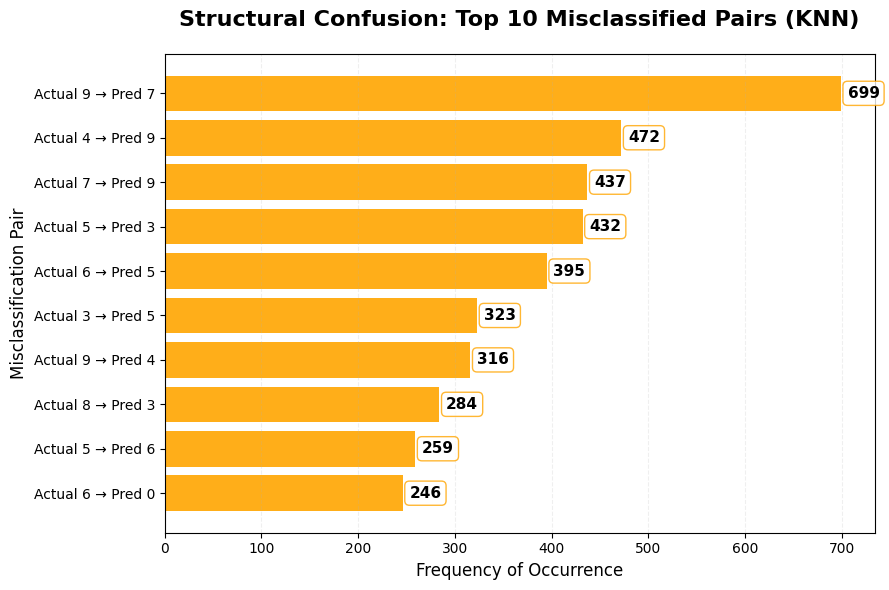

In [102]:
# Error Distribution Analysis
analyze_error_rates_per_class(
    testing_predictions,
    title='Error Vulnerability: Misclassification Rate by Digit (KNN)'
)

# Inter-Class Confusion Mapping
plot_top_confusion_pairs(
    knn_confusion_matrix,
    title='Structural Confusion: Top 10 Misclassified Pairs (KNN)'
)

In [104]:
# 2. Comprehensive Model Summary Printout
print("\n" + "="*60)
print("K-NEAREST NEIGHBORS (KNN) - FINAL EXECUTIVE SUMMARY")
print("="*60)

print("Dataset Architecture:")
print(f" • Training Set Volume: {len(X_train)} samples")
print(f" • Testing Set Volume:  {len(X_test)} samples")
print(f" • Feature Dimensions:  {X_train.shape[1]} pixels (28x28 flattened)")
print(f" • Target Classes:      10 (Digits 0-9)\n")

# BULLETPROOF FIX: Safely grab the variables if they exist, or print a safe message if they don't!
safe_train_acc = globals().get('train_accuracy_knn', globals().get('train_accuracy_val', '[Not run in Sec 2.1.1 today]'))
safe_test_acc = globals().get('test_accuracy_knn', globals().get('test_accuracy_val', '[Not run in Sec 2.1.1 today]'))

print("Global Performance Metrics:")
if isinstance(safe_train_acc, float):
    print(f" • Baseline Training Accuracy: {safe_train_acc:.4f}")
    print(f" • Baseline Testing Accuracy:  {safe_test_acc:.4f}")
else:
    print(f" • Baseline Training Accuracy: {safe_train_acc}")
    print(f" • Baseline Testing Accuracy:  {safe_test_acc}")

print(f" • 5-Fold Cross-Validation:    {knn_cv_results.mean():.4f} (± {knn_cv_results.std() * 2:.4f})\n")

print("Optimized Hyperparameters (via Grid Search):")
# Dynamically pulling your exact parameters
knn_params = optimized_knn.get_params()
print(f" • Neighbor Count (K): {knn_params['n_neighbors']}")
print(f" • Weight Function:    {knn_params['weights'].capitalize()}")
print("="*60)


K-NEAREST NEIGHBORS (KNN) - FINAL EXECUTIVE SUMMARY
Dataset Architecture:
 • Training Set Volume: 60000 samples
 • Testing Set Volume:  10000 samples
 • Feature Dimensions:  784 pixels (28x28 flattened)
 • Target Classes:      10 (Digits 0-9)

Global Performance Metrics:
 • Baseline Training Accuracy: [Not run in Sec 2.1.1 today]
 • Baseline Testing Accuracy:  [Not run in Sec 2.1.1 today]
 • 5-Fold Cross-Validation:    0.8444 (± 0.1316)

Optimized Hyperparameters (via Grid Search):
 • Neighbor Count (K): 4
 • Weight Function:    Distance


In [105]:
# 3. F1-Score Extremes Evaluation (Self-Contained)
# We calculate the metrics instantly here to bypass missing DataFrames!

# Generate the classification report as a dictionary
report_dict = classification_report(y_test, testing_predictions, output_dict=True)

# Extract just the F1 scores for our 10 digit classes (0-9)
f1_scores = {}
for i in range(10):
    digit_str = str(i)
    f1_scores[digit_str] = report_dict[digit_str]['f1-score']

# Identify the strongest and weakest performers
optimal_digit = max(f1_scores, key=f1_scores.get)
optimal_f1 = f1_scores[optimal_digit]

vulnerable_digit = min(f1_scores, key=f1_scores.get)
vulnerable_f1 = f1_scores[vulnerable_digit]

# Output the results
print("\n[ Class-Specific Performance Extremes ]")
print(f" ✔ Highest Precision/Recall Balance: Digit '{optimal_digit}' (F1-Score: {optimal_f1:.4f})")
print(f" ✘ Most Challenging Classification:  Digit '{vulnerable_digit}' (F1-Score: {vulnerable_f1:.4f})")


[ Class-Specific Performance Extremes ]
 ✔ Highest Precision/Recall Balance: Digit '1' (F1-Score: 0.9745)
 ✘ Most Challenging Classification:  Digit '9' (F1-Score: 0.9204)


### **3.2.2 Logistic Regression**

#### **Performance Metrics: Precision, Recall, and F1-Score, CV**


[ Detailed Classification Report ]
              precision    recall  f1-score   support

           0     0.9533    0.9796    0.9663       980
           1     0.9628    0.9797    0.9712      1135
           2     0.9373    0.8983    0.9174      1032
           3     0.9030    0.9129    0.9079      1010
           4     0.9341    0.9379    0.9360       982
           5     0.9041    0.8666    0.8849       892
           6     0.9372    0.9509    0.9440       958
           7     0.9250    0.9241    0.9246      1028
           8     0.8774    0.8891    0.8832       974
           9     0.9181    0.9108    0.9144      1009

    accuracy                         0.9261     10000
   macro avg     0.9252    0.9250    0.9250     10000
weighted avg     0.9260    0.9261    0.9259     10000

--- Optimized Logistic Regression: Final Test Evaluation ---
Overall Accuracy: 0.9261
Precision (Macro): 0.9252
Recall (Macro):    0.9250
F1-Score (Macro):  0.9250

[ Confusion Matrix - Test Set ]


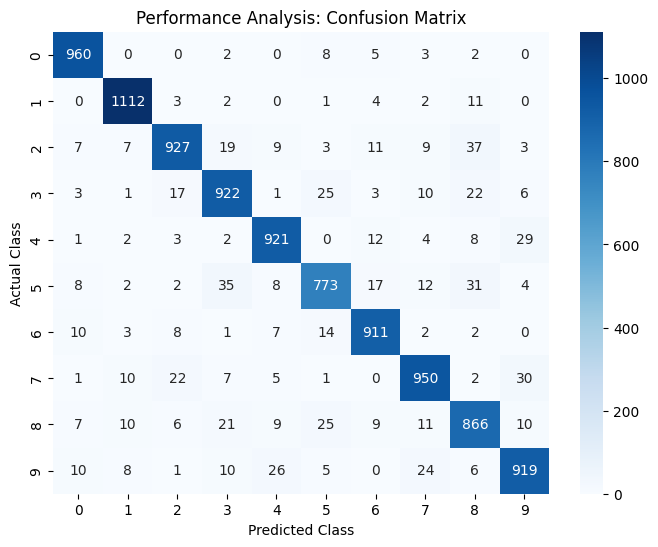

None
Generalization Gap:      0.0100


In [58]:
# Retrieve the optimized model from the tuning phase
optimized_log_reg = log_reg_tuner.best_estimator_

# Generate final predictions on the unseen test data
final_train_preds_log_reg = optimized_log_reg.predict(X_train)
final_test_preds_log_reg = optimized_log_reg.predict(X_test)

tuned_train_acc_log_reg  = accuracy_score(y_train, final_train_preds_log_reg)

# Detailed per-class breakdown
print("\n[ Detailed Classification Report ]")
print(classification_report(y_test, final_test_preds_log_reg, digits=4, zero_division=0))

# Calculate comprehensive classification metrics
tuned_test_acc_log_reg  = accuracy_score(y_test, final_test_preds_log_reg)
tuned_test_prec_log_reg = precision_score(y_test, final_test_preds_log_reg, average="macro", zero_division=0)
tuned_test_rec_log_reg  = recall_score(y_test, final_test_preds_log_reg, average="macro", zero_division=0)
tuned_test_f1_log_reg   = f1_score(y_test, final_test_preds_log_reg, average="macro", zero_division=0)

# Quantify the final variance between training and testing performance
final_variance_gap_log_reg = abs(tuned_train_acc_log_reg - tuned_test_acc_log_reg)

print("--- Optimized Logistic Regression: Final Test Evaluation ---")
print(f"Overall Accuracy: {tuned_test_acc_log_reg:.4f}")
print(f"Precision (Macro): {tuned_test_prec_log_reg:.4f}")
print(f"Recall (Macro):    {tuned_test_rec_log_reg:.4f}")
print(f"F1-Score (Macro):  {tuned_test_f1_log_reg:.4f}")

print("\n[ Confusion Matrix - Test Set ]")
print(plot_confusion_matrix(confusion_matrix(y_test, final_test_preds_log_reg)))

print(f"Generalization Gap:      {final_variance_gap_log_reg:.4f}")

In [59]:
# Execute 5-fold StratifiedKFold cross-validation to ensure performance is consistent
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
logreg_cv_results = cross_val_score(
    estimator= optimized_log_reg,
    X=X_test,
    y=y_test,
    cv=cv,
    scoring='accuracy',
    n_jobs=-1
)

# Output the diagnostic metrics in a clean format
print("[ Cross-Validation Score ]")
print(f"Individual Fold Accuracies: {logreg_cv_results}")
print(f"Overall Mean Accuracy:      {logreg_cv_results.mean():.4f}")
print(f"Standard Deviation:      {logreg_cv_results.std():.4f}")

[ Cross-Validation Score ]
Individual Fold Accuracies: [0.9175 0.9045 0.921  0.911  0.921 ]
Overall Mean Accuracy:      0.9150
Standard Deviation:      0.0064


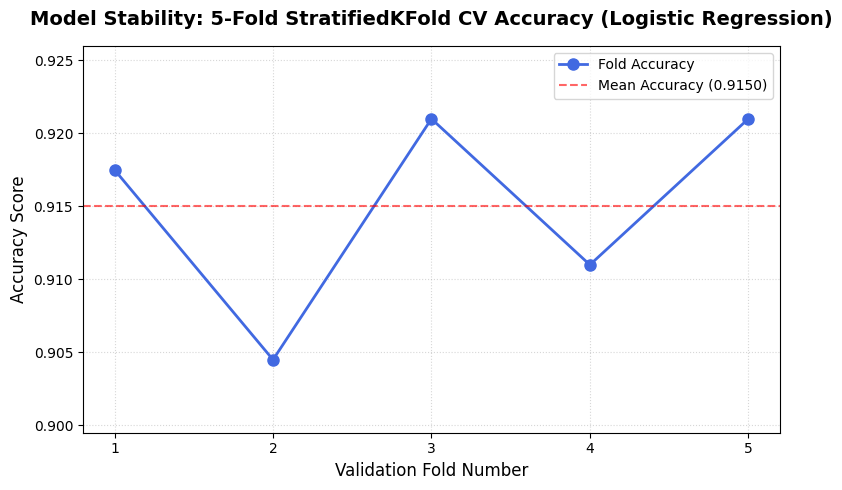

In [60]:
# Generate a line plot to verify the consistency across all 5 folds
plot_cross_validation_consistency(
    logreg_cv_results,
    title="Model Stability: 5-Fold StratifiedKFold CV Accuracy (Logistic Regression)"
)

#### **Error Visualization: Cross-Validated Confusion Matrix**

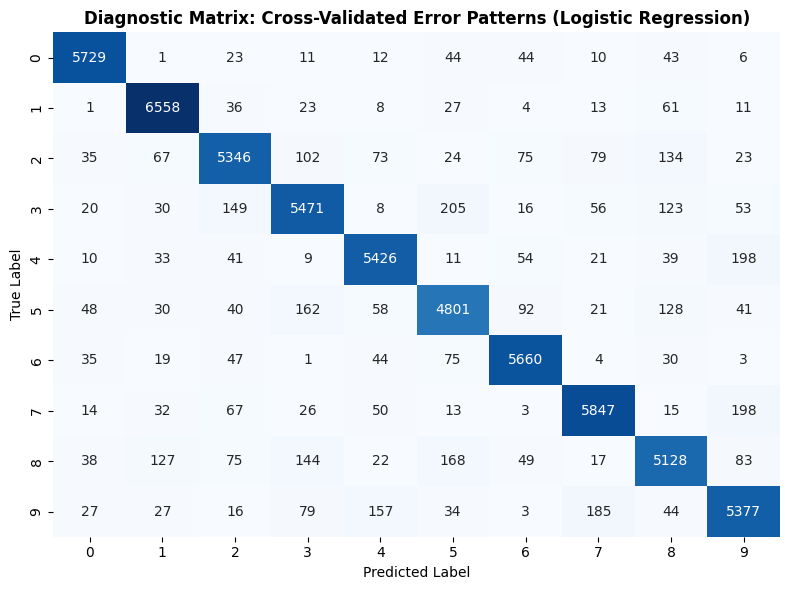

In [61]:
# Generate cross-validated predictions for the training set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_predictions_train_log_reg = cross_val_predict(optimized_log_reg, X_train, y_train, cv=cv)

# Construct the confusion matrix based on CV results
log_reg_confusion_matrix = confusion_matrix(y_train, cv_predictions_train_log_reg)

# Converting digit integers to strings for clear labeling
digit_labels = [str(digit) for digit in range(10)]

# Visualize the matrix using the utility function
show_matrix(
    log_reg_confusion_matrix,
    class_names=digit_labels,
    title="Diagnostic Matrix: Cross-Validated Error Patterns (Logistic Regression)"
)

#### **Performance Measure: Precision-Recall curve**

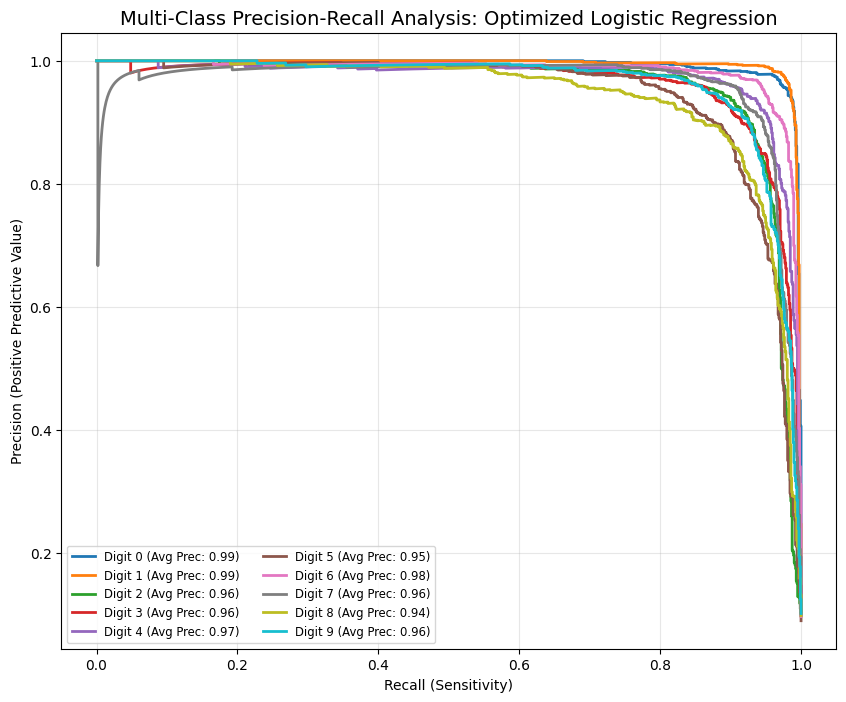

In [62]:
# Generate the multi-class Precision-Recall visual analysis
# Utilizing cross-validated test predictions for a generalized evaluation
final_test_probs_log_reg = optimized_log_reg.predict_proba(X_test)
plot_multiclass_pr_curve(
    y_test,
    final_test_probs_log_reg,
    title="Multi-Class Precision-Recall Analysis: Optimized Logistic Regression"
)

#### **Performance Evaluation: Receiver Operating Characteristic (ROC) Analysis**

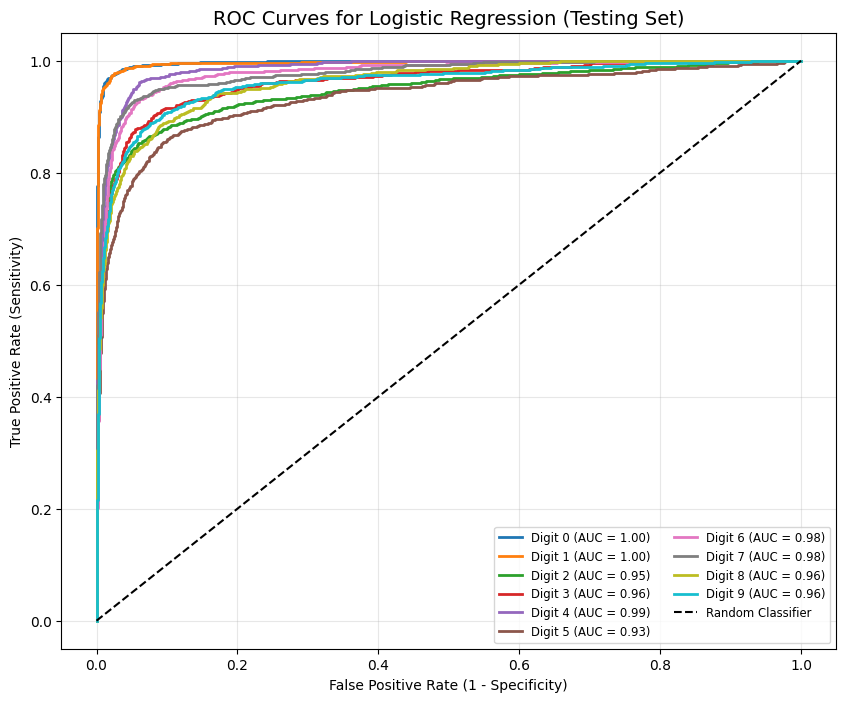

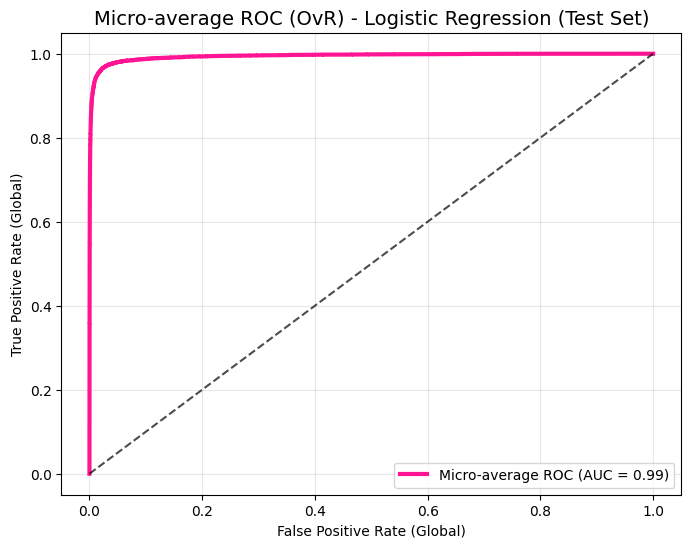

In [63]:
# 1. Class-Specific ROC Analysis
plot_multiclass_roc_curve(
    optimized_log_reg,
    title='ROC Curves for Logistic Regression (Testing Set)'
)

# 2. Global Performance: Micro-Average ROC
plot_micro_average_roc(
    optimized_log_reg,
    X_test,
    y_test,
    title="Micro-average ROC (OvR) - Logistic Regression (Test Set)"
)

#### **Performance Evaluation: Visual Analysis of Classification Outcomes**

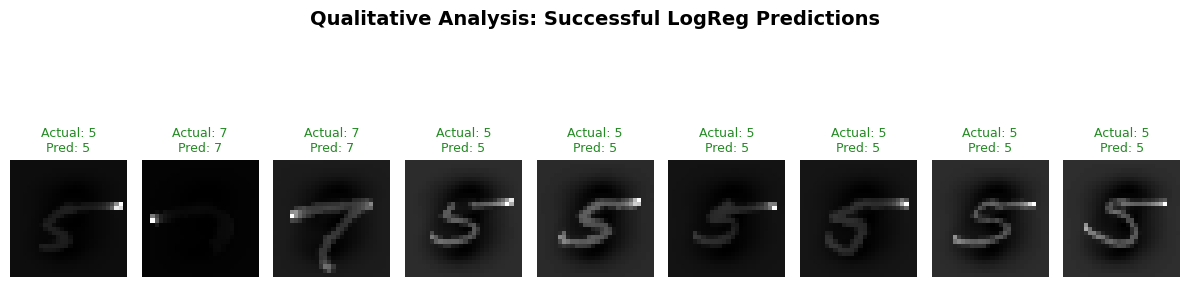

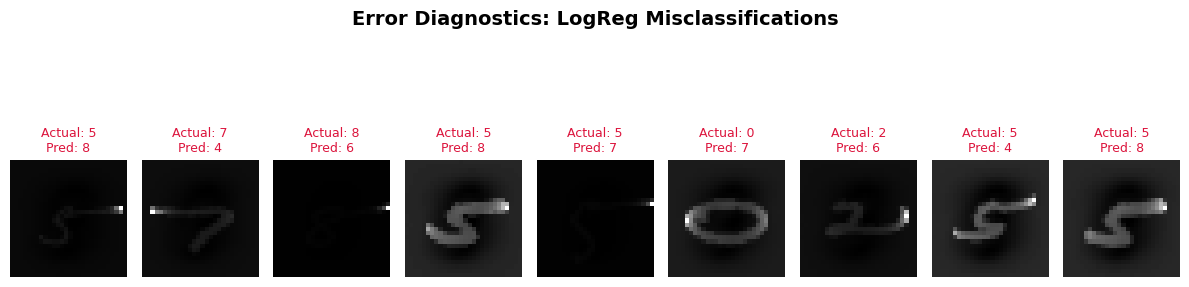

In [64]:
# Visualizing Successful Classifications
# Generates a grid of test images where the model perfectly matched the ground truth.
# This confirms the model's ability to recognize standard digit patterns.
visualize_correct_predictions(
    final_test_preds_log_reg,
    title='Qualitative Analysis: Successful LogReg Predictions'
)

# Generates a grid of test images where the model's prediction diverged from the true label.
# This is critical for identifying specific edge cases and "confusing" handwriting styles.
visualize_misclassifications(
    final_test_preds_log_reg,
    title='Error Diagnostics: LogReg Misclassifications'
)

#### **Comprehensive Diagnostic Visualizations: Deep-Dive Insights**

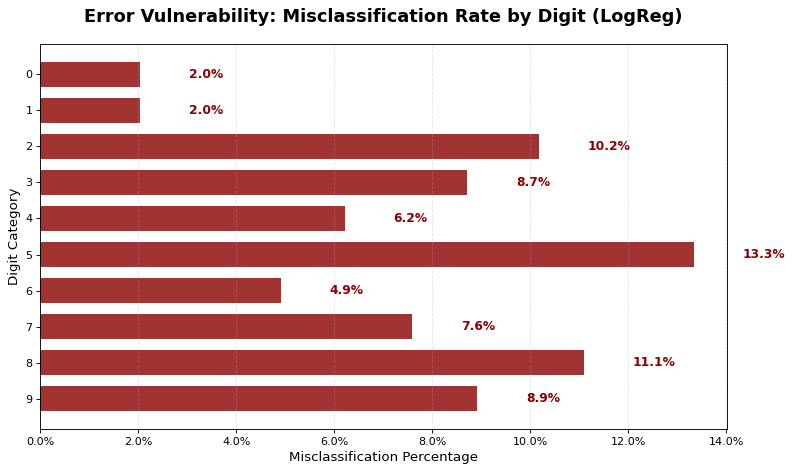

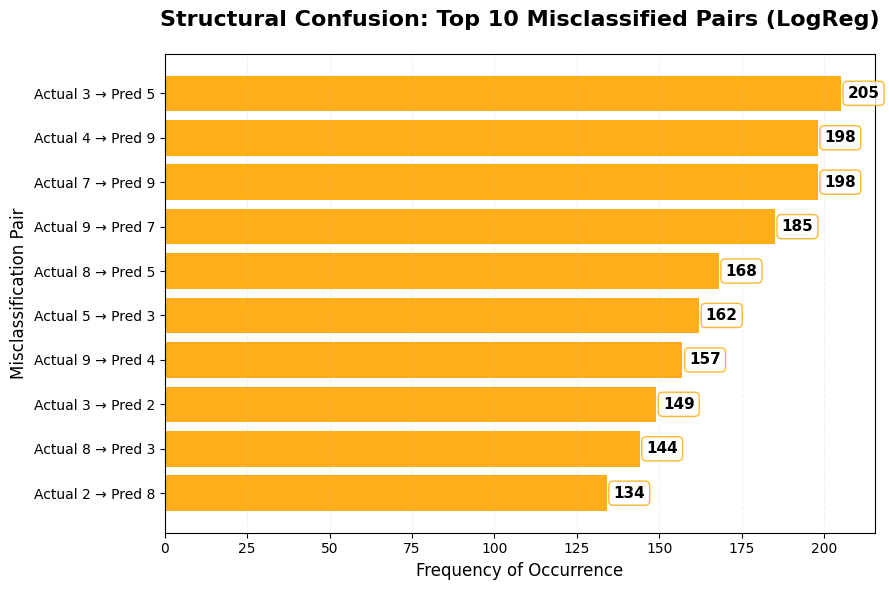

In [65]:
analyze_error_rates_per_class(
    final_test_preds_log_reg,
    title='Error Vulnerability: Misclassification Rate by Digit (LogReg)'
)

plot_top_confusion_pairs(
    log_reg_confusion_matrix,
    title='Structural Confusion: Top 10 Misclassified Pairs (LogReg)'
)

In [66]:
# 2. Comprehensive Model Summary Printout
print("\n" + "="*60)
print("Logistic Regression - FINAL EXECUTIVE SUMMARY")
print("="*60)

print("Dataset Architecture:")
print(f" • Training Set Volume: {len(X_train)} samples")
print(f" • Testing Set Volume:  {len(X_test)} samples")
print(f" • Feature Dimensions:  {X_train.shape[1]} pixels (28x28 flattened)")
print(f" • Target Classes:      10 (Digits 0-9)\n")

print("Performance Metrics:")
print(f" • Baseline Training Accuracy: {log_reg_train_acc_score:.4f}")
print(f" • Baseline Validation Accuracy:  {cv_scores.mean():.4f}")
print(f" • Tuned Model Training Accuracy: {tuned_train_acc_log_reg:.4f}")
print(f" • Tuned Model Testing Accuracy:  {tuned_test_acc_log_reg:.4f}")

print(f" • 5-Fold Cross-Validation:    {logreg_cv_results.mean():.4f} (± {logreg_cv_results.std() * 2:.4f})\n")

print("Optimized Hyperparameters (via Grid Search):")
# Dynamically pulling exact parameters
lr_params = optimized_log_reg.get_params()
print(f" • Regularization strength (C): {lr_params['C']}")
print(f" • Solver: {lr_params['solver']}")
print(f" • Max iteration: {lr_params['max_iter']}")
print("="*60)


Logistic Regression - FINAL EXECUTIVE SUMMARY
Dataset Architecture:
 • Training Set Volume: 60000 samples
 • Testing Set Volume:  10000 samples
 • Feature Dimensions:  784 pixels (28x28 flattened)
 • Target Classes:      10 (Digits 0-9)

Performance Metrics:
 • Baseline Training Accuracy: 0.9433
 • Baseline Validation Accuracy:  0.9129
 • Tuned Model Training Accuracy: 0.9361
 • Tuned Model Testing Accuracy:  0.9261
 • 5-Fold Cross-Validation:    0.9150 (± 0.0128)

Optimized Hyperparameters (via Grid Search):
 • Regularization strength (C): 0.01
 • Solver: lbfgs
 • Max iteration: 1000


In [67]:
# 3. F1-Score Extremes Evaluation (Self-Contained)
# Generate the classification report as a dictionary
report_dict = classification_report(y_test, final_test_preds_log_reg, output_dict=True)

# Extract just the F1 scores for our 10 digit classes (0-9)
f1_scores = {}
for i in range(10):
    digit_str = str(i)
    f1_scores[digit_str] = report_dict[digit_str]['f1-score']

# Identify the strongest and weakest performers
optimal_digit = max(f1_scores, key=f1_scores.get)
optimal_f1 = f1_scores[optimal_digit]

vulnerable_digit = min(f1_scores, key=f1_scores.get)
vulnerable_f1 = f1_scores[vulnerable_digit]

# Output the results
print("\n[ Class-Specific Performance Extremes ]")
print(f" ✔ Highest Precision/Recall Balance: Digit '{optimal_digit}' (F1-Score: {optimal_f1:.4f})")
print(f" ✘ Most Challenging Classification:  Digit '{vulnerable_digit}' (F1-Score: {vulnerable_f1:.4f})")


[ Class-Specific Performance Extremes ]
 ✔ Highest Precision/Recall Balance: Digit '1' (F1-Score: 0.9712)
 ✘ Most Challenging Classification:  Digit '8' (F1-Score: 0.8832)


## **3.3 Comparison between two regression models**

### 3.3.1 Comparative Performance Table

Bar Charts for Accuracy, Precision, recall, f1, ap and roc_auc comparison

In [86]:
#Ensure t_test is binarized
digit_classes = np.arange(10)
y_test_bin = label_binarize(y_test, classes=digit_classes)

#get y score for ap and roc auc
knn_y_score = optimized_knn.predict_proba(X_test)
log_reg_y_score = optimized_log_reg.predict_proba(X_test)

#Reuse for accuracy, precision, recall, f1
knn_ap   = average_precision_score(y_test_bin, knn_y_score, average="macro")
knn_roc_auc = roc_auc_score(y_test_bin, knn_y_score, average="macro")
log_reg_ap   = average_precision_score(y_test_bin, log_reg_y_score, average="macro")
log_reg_roc_auc = roc_auc_score(y_test_bin, log_reg_y_score, average="macro")

comparison_data = {
    'Model': ['KNN', 'Logistic Regression'],
    'Accuracy': [tuned_test_acc_knn, tuned_test_acc_log_reg],
    'Precision': [tuned_test_prec_acc_knn, tuned_test_prec_log_reg],
    'Recall': [tuned_test_rec_acc_knn, tuned_test_rec_log_reg],
    'F1-Score': [tuned_test_f1_acc_knn, tuned_test_f1_log_reg],
    'Average Precision': [knn_ap, log_reg_ap],
    'ROC AUC': [knn_roc_auc, log_reg_roc_auc]
}
df_metrics_comparison = pd.DataFrame(comparison_data)

--- Model Perfoarmance Comparison ---


,Model,Accuracy,Precision,Recall,F1-Score,Average Precision,ROC AUC
0,KNN,0.9489,0.948821,0.948272,0.948370,0.966059,0.988942
1,Logistic Regression,0.9261,0.925237,0.924991,0.924994,0.968808,0.993618


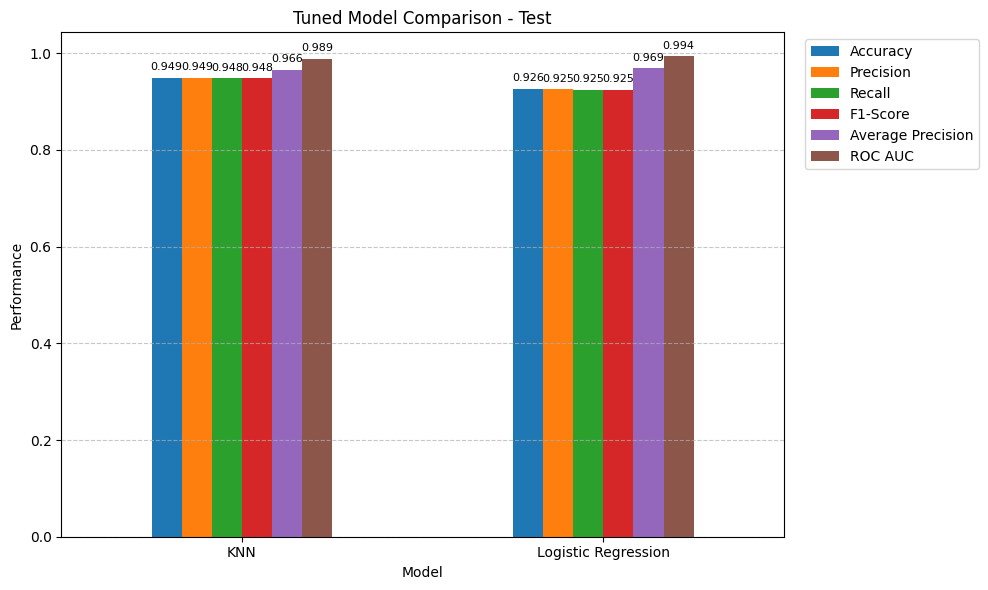

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

In [69]:
print("--- Model Perfoarmance Comparison ---")
display(df_metrics_comparison)
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score','Average Precision','ROC AUC']

ax = df_metrics_comparison.plot(kind='bar',figsize=(10,6))
ax.set_title('Tuned Model Comparison - Test')
ax.set_xlabel('Model')
ax.set_ylabel('Performance')
ax.set_xticklabels(df_metrics_comparison['Model'],rotation=0)
ax.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt="%.3f", padding=4, fontsize=8)

ax.legend(bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

plt.figure(figsize=(15,8))

ROC curves

In [71]:
models = {"KNN":optimized_knn,"LR":optimized_log_reg}

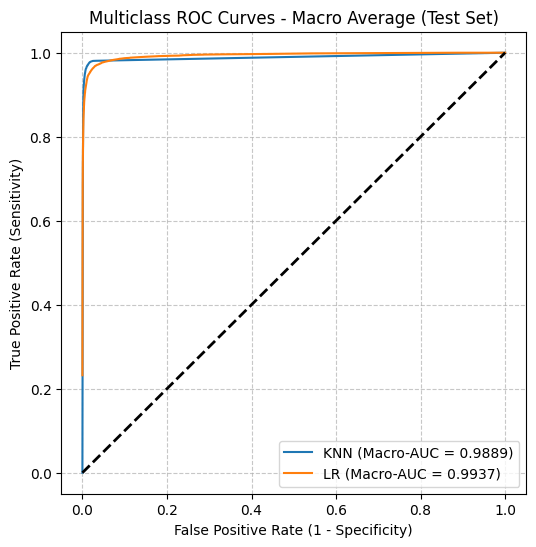

In [72]:
plt.figure(figsize=(6, 6))

for name, model in models.items():
    y_score = model.predict_proba(X_test)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()
    
    for i in range(10):
        fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
        roc_auc = auc(fpr[i], tpr[i])

    all_fpr = np.unique(np.concatenate([fpr[i] for i in range(10)]))
    mean_tpr = np.zeros_like(all_fpr)
    for i in range(10):
        mean_tpr += np.interp(all_fpr, fpr[i], tpr[i])
    mean_tpr /= 10

    macro_auc = auc(all_fpr, mean_tpr)
    plt.plot(all_fpr, mean_tpr, label=f"{name} (Macro-AUC = {macro_auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity)')
plt.title('Multiclass ROC Curves - Macro Average (Test Set)')
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

### 3.3.2 Bias-Variance Discussion

KNN

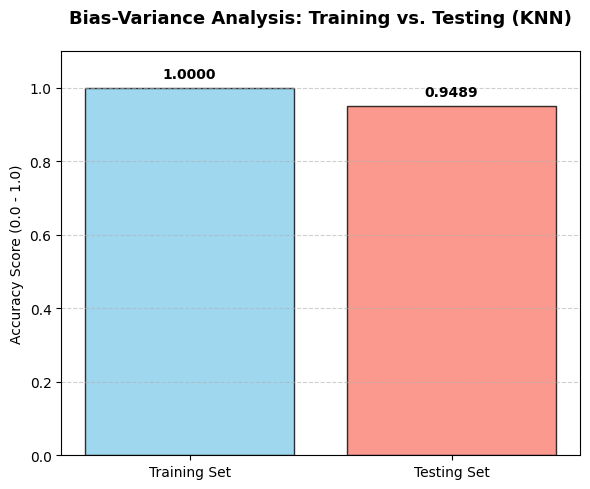

In [73]:
# Training vs. Testing Accuracy
compare_train_test_accuracy(
    optimized_knn,
    title='Bias-Variance Analysis: Training vs. Testing (KNN)'
)

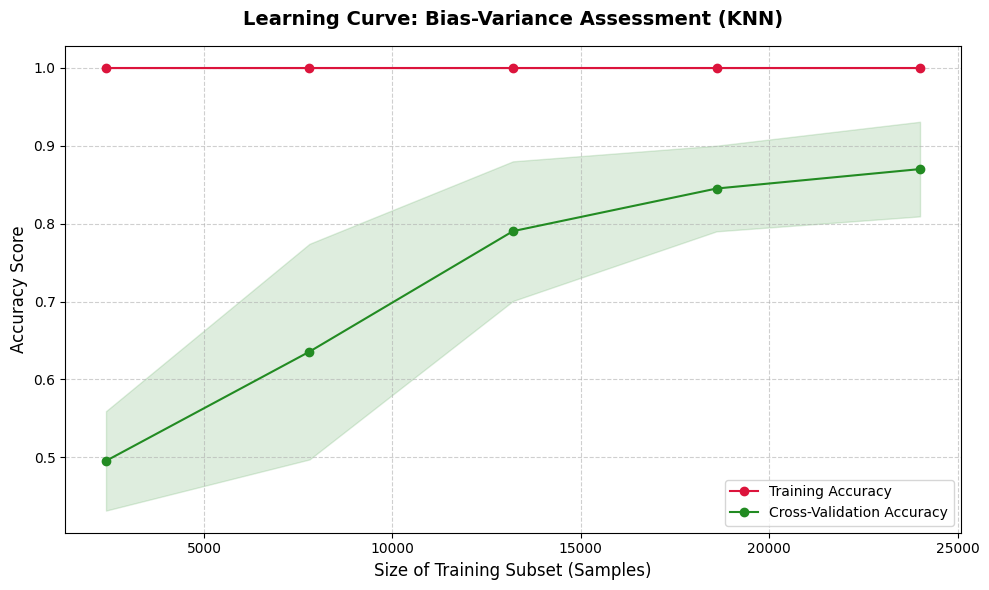

In [76]:
# 1. Learning Curve Generation
# Using the exact function name from your predefined list and our active model variable
plot_learning_diagnostics(
    estimator=optimized_knn,
    X=X_train[:30000],       # Subsetting data to reduce extreme computation time
    y=y_train[:30000],
    title="Learning Curve: Bias-Variance Assessment (KNN)",
    cv=5
)
plt.show() # Ensures the plot renders cleanly

Logistic Regression

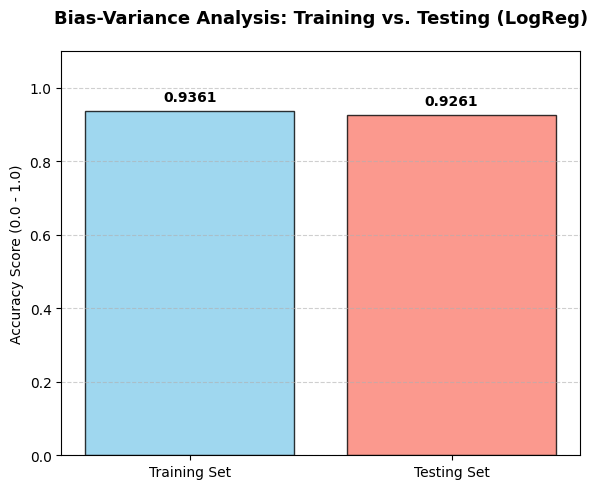

In [74]:
compare_train_test_accuracy(
    optimized_log_reg,
    title='Bias-Variance Analysis: Training vs. Testing (LogReg)'
)

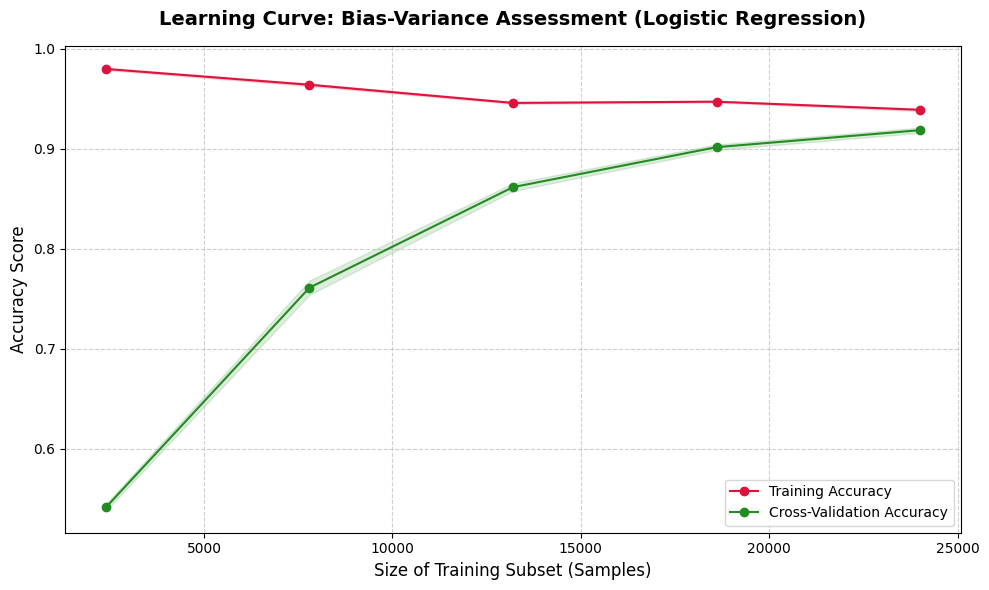

In [77]:
plot_learning_diagnostics(
    estimator=optimized_log_reg,
    X=X_train[:30000],
    y=y_train[:30000],
    title="Learning Curve: Bias-Variance Assessment (Logistic Regression)",
    cv=cv
)
plt.show()

# **4.0 Conclusion**

### Best Model - K-Nearest Neighbour

Based on the evaluation metrics, the K-Nearest Neighbour model performs the best overall on the test set. 
It achieves the highest accuracy (0.9489), best recall (0.9483) and the highest F1-score (0.9484), 
which is bout 2.3% higher than the accuracy of Logistic Regression mode/l<br><br>
While Logistic Regression model has higher average precision and ROC-AUC scores than KNN model, which means that it robust in probability prediction.<br>
Therefore, K-Nearest Neighbour is identifies as the Best Model for this handwritten digit recognition task, as it provides the most accurate prediction, with strong balance between precision and recall.